In [1]:
from rdkit import Chem
from rdkit.Chem import AllChem, MACCSkeys, Descriptors
from rdkit import DataStructs
import numpy as np
import pandas as pd

smiles = "CCO"  # ethanol
mol = Chem.MolFromSmiles(smiles)

print("Molecule loaded:", mol is not None)
print("Number of atoms:", mol.GetNumAtoms())

Molecule loaded: True
Number of atoms: 3


In [2]:
# Morgan fingerprint / circular fingerprint
morgan_fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)

morgan_arr = np.zeros((2048,), dtype=int)
DataStructs.ConvertToNumpyArray(morgan_fp, morgan_arr)

print("Morgan fingerprint length:", len(morgan_arr))
print("Number of active bits:", morgan_arr.sum())
print("First 50 bits:", morgan_arr[:50])

Morgan fingerprint length: 2048
Number of active bits: 6
First 50 bits: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]


[16:07:48] DEPRECATION WARNING: please use MorganGenerator


In [3]:
example_compounds = pd.DataFrame({
    "name": ["ethanol", "aspirin", "caffeine", "ibuprofen"],
    "smiles": [
        "CCO",
        "CC(=O)OC1=CC=CC=C1C(=O)O",
        "Cn1cnc2c1c(=O)n(C)c(=O)n2C",
        "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O"
    ]
})

example_compounds

,name,smiles
0,ethanol,CCO
1,aspirin,CC(=O)OC1=CC=CC=C1C(=O)O
2,caffeine,Cn1cnc2c1c(=O)n(C)c(=O)n2C
3,ibuprofen,CC(C)CC1=CC=C(C=C1)C(C)C(=O)O


In [4]:
def smiles_to_morgan_array(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is None:
        return None
    
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    
    return arr

fingerprints = []

for smiles in example_compounds["smiles"]:
    arr = smiles_to_morgan_array(smiles)
    fingerprints.append(arr)

fingerprint_df = pd.DataFrame(fingerprints)
fingerprint_df.insert(0, "name", example_compounds["name"])
fingerprint_df.insert(1, "smiles", example_compounds["smiles"])

fingerprint_df.head()

[16:09:21] DEPRECATION WARNING: please use MorganGenerator
[16:09:21] DEPRECATION WARNING: please use MorganGenerator
[16:09:21] DEPRECATION WARNING: please use MorganGenerator
[16:09:21] DEPRECATION WARNING: please use MorganGenerator


,name,smiles,0,1,2,3,4,5,6,7,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,ethanol,CCO,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,aspirin,CC(=O)OC1=CC=CC=C1C(=O)O,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,caffeine,Cn1cnc2c1c(=O)n(C)c(=O)n2C,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,ibuprofen,CC(C)CC1=CC=C(C=C1)C(C)C(=O)O,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
fingerprint_df.to_csv("example_morgan_fingerprints.csv", index=False)
print("Saved example_morgan_fingerprints.csv")

Saved example_morgan_fingerprints.csv


In [1]:
# json

In [2]:
from pathlib import Path
import json

file_path = Path.home() / "predicting-predictability" / "data" / "drug_master.json"

print(file_path)
print("File exists:", file_path.exists())
print("File size MB:", file_path.stat().st_size / 1_000_000)

with open(file_path, "r") as f:
    drug_master = json.load(f)

print(type(drug_master))
print(len(drug_master))

/Users/mell/predicting-predictability/data/drug_master.json
File exists: True
File size MB: 2.959962
<class 'dict'>
6801


In [3]:
if isinstance(drug_master, dict):
    first_key = list(drug_master.keys())[0]
    print("First key:", first_key)
    print(drug_master[first_key])
else:
    print(drug_master[0])

First key: be-2254
{'name': 'be-2254', 'pubchem_cid': '86308637', 'inchi_key': 'PZZOEXPDTYIBPI-MRXNPFEDSA-N', 'smiles': 'Oc1ccc(CCNC[C@H]2CCc3ccccc3C2=O)cc1 |r|', 'broad_id': 'BRD-A24429032-003-03-2', 'moa': 'adrenergic receptor antagonist', 'target': 'ADRA1A', 'clinical_phase': 'Phase 2', 'disease_area': '', 'indication': '', 'fda_approved': False}


In [4]:
import pandas as pd

drugs_df = pd.DataFrame.from_dict(drug_master, orient="index")
drugs_df.insert(0, "record_id", drugs_df.index)

print(drugs_df.shape)
drugs_df.head()

(6801, 12)


,record_id,name,pubchem_cid,inchi_key,smiles,broad_id,moa,target,clinical_phase,disease_area,indication,fda_approved
be-2254,be-2254,be-2254,86308637,PZZOEXPDTYIBPI-MRXNPFEDSA-N,Oc1ccc(CCNC[C@H]2CCc3ccccc3C2=O)cc1 |r|,BRD-A24429032-003-03-2,adrenergic receptor antagonist,ADRA1A,Phase 2,,,False
tasimelteon,tasimelteon,tasimelteon,10220503,PTOIAAWZLUQTIO-GXFFZTMASA-N,CCC(=O)NC[C@@H]1C[C@H]1c1cccc2OCCc12,BRD-K62971431-001-01-9,melatonin receptor agonist,MTNR1A|MTNR1B,Launched,neurology/psychiatry,Non-24-Hour Sleep-Wake Disorder,True
esaxerenone,esaxerenone,esaxerenone,25052023,NOSNHVJANRODGR-UHFFFAOYSA-N,Cc1c(cn(CCO)c1-c1ccccc1C(F)(F)F)C(=O)Nc1ccc(cc...,BRD-K00003374-001-01-9,mineralocorticoid receptor antagonist,,Preclinical,,,False
ixazomib-citrate,ixazomib-citrate,ixazomib-citrate,69040311,YTXSYWAKVMZICI-VBKZILBWSA-N,CC(C)C[C@H](NC(=O)CNC(=O)c1cc(Cl)ccc1Cl)B1OC(=...,BRD-A66419424-001-02-4,proteasome inhibitor,,Launched,hematologic malignancy,multiple myeloma,True
alendronate,alendronate,alendronate,44400013,OGSPWJRAVKPPFI-UHFFFAOYSA-N,NCCCC(O)(P(O)(O)=O)P(O)(O)=O,BRD-K75527158-360-05-6,bone resorption inhibitor,ATP6V1A|FDPS|PTPN4|PTPRE|PTPRS,Launched,orthopedics,osteoporosis,True


In [5]:
smiles_col = "smiles"

drugs_with_smiles = drugs_df[
    drugs_df[smiles_col].notna() &
    (drugs_df[smiles_col].astype(str).str.strip() != "")
].copy()

print("Compounds with SMILES:", drugs_with_smiles.shape[0])
drugs_with_smiles.head()

Compounds with SMILES: 6776


,record_id,name,pubchem_cid,inchi_key,smiles,broad_id,moa,target,clinical_phase,disease_area,indication,fda_approved
be-2254,be-2254,be-2254,86308637,PZZOEXPDTYIBPI-MRXNPFEDSA-N,Oc1ccc(CCNC[C@H]2CCc3ccccc3C2=O)cc1 |r|,BRD-A24429032-003-03-2,adrenergic receptor antagonist,ADRA1A,Phase 2,,,False
tasimelteon,tasimelteon,tasimelteon,10220503,PTOIAAWZLUQTIO-GXFFZTMASA-N,CCC(=O)NC[C@@H]1C[C@H]1c1cccc2OCCc12,BRD-K62971431-001-01-9,melatonin receptor agonist,MTNR1A|MTNR1B,Launched,neurology/psychiatry,Non-24-Hour Sleep-Wake Disorder,True
esaxerenone,esaxerenone,esaxerenone,25052023,NOSNHVJANRODGR-UHFFFAOYSA-N,Cc1c(cn(CCO)c1-c1ccccc1C(F)(F)F)C(=O)Nc1ccc(cc...,BRD-K00003374-001-01-9,mineralocorticoid receptor antagonist,,Preclinical,,,False
ixazomib-citrate,ixazomib-citrate,ixazomib-citrate,69040311,YTXSYWAKVMZICI-VBKZILBWSA-N,CC(C)C[C@H](NC(=O)CNC(=O)c1cc(Cl)ccc1Cl)B1OC(=...,BRD-A66419424-001-02-4,proteasome inhibitor,,Launched,hematologic malignancy,multiple myeloma,True
alendronate,alendronate,alendronate,44400013,OGSPWJRAVKPPFI-UHFFFAOYSA-N,NCCCC(O)(P(O)(O)=O)P(O)(O)=O,BRD-K75527158-360-05-6,bone resorption inhibitor,ATP6V1A|FDPS|PTPN4|PTPRE|PTPRS,Launched,orthopedics,osteoporosis,True


In [6]:
# real morgan

In [7]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs
import numpy as np
import pandas as pd

def smiles_to_morgan_array(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(str(smiles))
    
    if mol is None:
        return None
    
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    
    return arr

fingerprints = []
valid_rows = []
invalid_smiles = []

for idx, row in drugs_with_smiles.iterrows():
    smiles = row["smiles"]
    arr = smiles_to_morgan_array(smiles)
    
    if arr is None:
        invalid_smiles.append((idx, smiles))
    else:
        fingerprints.append(arr)
        valid_rows.append(row)

valid_drugs_df = pd.DataFrame(valid_rows).reset_index(drop=True)

morgan_df = pd.DataFrame(
    fingerprints,
    columns=[f"morgan_{i}" for i in range(2048)]
)

perturbseqr_morgan_df = pd.concat(
    [valid_drugs_df.reset_index(drop=True), morgan_df],
    axis=1
)

print("Valid compounds:", perturbseqr_morgan_df.shape[0])
print("Invalid SMILES:", len(invalid_smiles))
print("Final table shape:", perturbseqr_morgan_df.shape)

perturbseqr_morgan_df.head()

[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerator
[16:45:12] DEPRECATION WARNING: please use MorganGenerat

Valid compounds: 6754
Invalid SMILES: 22
Final table shape: (6754, 2060)


,record_id,name,pubchem_cid,inchi_key,smiles,broad_id,moa,target,clinical_phase,disease_area,...,morgan_2038,morgan_2039,morgan_2040,morgan_2041,morgan_2042,morgan_2043,morgan_2044,morgan_2045,morgan_2046,morgan_2047
0,be-2254,be-2254,86308637,PZZOEXPDTYIBPI-MRXNPFEDSA-N,Oc1ccc(CCNC[C@H]2CCc3ccccc3C2=O)cc1 |r|,BRD-A24429032-003-03-2,adrenergic receptor antagonist,ADRA1A,Phase 2,,...,0,0,0,0,0,0,0,0,0,0
1,tasimelteon,tasimelteon,10220503,PTOIAAWZLUQTIO-GXFFZTMASA-N,CCC(=O)NC[C@@H]1C[C@H]1c1cccc2OCCc12,BRD-K62971431-001-01-9,melatonin receptor agonist,MTNR1A|MTNR1B,Launched,neurology/psychiatry,...,0,0,0,0,0,0,0,0,0,0
2,esaxerenone,esaxerenone,25052023,NOSNHVJANRODGR-UHFFFAOYSA-N,Cc1c(cn(CCO)c1-c1ccccc1C(F)(F)F)C(=O)Nc1ccc(cc...,BRD-K00003374-001-01-9,mineralocorticoid receptor antagonist,,Preclinical,,...,0,0,0,0,0,0,0,0,0,0
3,ixazomib-citrate,ixazomib-citrate,69040311,YTXSYWAKVMZICI-VBKZILBWSA-N,CC(C)C[C@H](NC(=O)CNC(=O)c1cc(Cl)ccc1Cl)B1OC(=...,BRD-A66419424-001-02-4,proteasome inhibitor,,Launched,hematologic malignancy,...,0,0,0,0,0,0,0,0,0,0
4,alendronate,alendronate,44400013,OGSPWJRAVKPPFI-UHFFFAOYSA-N,NCCCC(O)(P(O)(O)=O)P(O)(O)=O,BRD-K75527158-360-05-6,bone resorption inhibitor,ATP6V1A|FDPS|PTPN4|PTPRE|PTPRS,Launched,orthopedics,...,0,0,0,0,0,0,0,0,0,0


In [8]:
from pathlib import Path

output_path = Path.home() / "predicting-predictability" / "data" / "perturbseqr_morgan_fingerprints.csv"

perturbseqr_morgan_df.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: /Users/mell/predicting-predictability/data/perturbseqr_morgan_fingerprints.csv


In [9]:
# Generate MACCS keys for Perturb-Seqr compounds

In [10]:
from rdkit.Chem import MACCSkeys

def smiles_to_maccs_array(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    
    if mol is None:
        return None
    
    fp = MACCSkeys.GenMACCSKeys(mol)
    arr = np.zeros((167,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    
    return arr

maccs_fingerprints = []
valid_rows = []
invalid_maccs_smiles = []

for idx, row in drugs_with_smiles.iterrows():
    smiles = row["smiles"]
    arr = smiles_to_maccs_array(smiles)
    
    if arr is None:
        invalid_maccs_smiles.append((idx, smiles))
    else:
        maccs_fingerprints.append(arr)
        valid_rows.append(row)

valid_maccs_drugs_df = pd.DataFrame(valid_rows).reset_index(drop=True)

maccs_df = pd.DataFrame(
    maccs_fingerprints,
    columns=[f"maccs_{i}" for i in range(167)]
)

perturbseqr_maccs_df = pd.concat(
    [valid_maccs_drugs_df.reset_index(drop=True), maccs_df],
    axis=1
)

print("Valid compounds:", perturbseqr_maccs_df.shape[0])
print("Invalid SMILES:", len(invalid_maccs_smiles))
print("Final table shape:", perturbseqr_maccs_df.shape)

perturbseqr_maccs_df.head()

Valid compounds: 6754
Invalid SMILES: 22
Final table shape: (6754, 179)


,record_id,name,pubchem_cid,inchi_key,smiles,broad_id,moa,target,clinical_phase,disease_area,...,maccs_157,maccs_158,maccs_159,maccs_160,maccs_161,maccs_162,maccs_163,maccs_164,maccs_165,maccs_166
0,be-2254,be-2254,86308637,PZZOEXPDTYIBPI-MRXNPFEDSA-N,Oc1ccc(CCNC[C@H]2CCc3ccccc3C2=O)cc1 |r|,BRD-A24429032-003-03-2,adrenergic receptor antagonist,ADRA1A,Phase 2,,...,1,1,1,0,1,1,1,1,1,0
1,tasimelteon,tasimelteon,10220503,PTOIAAWZLUQTIO-GXFFZTMASA-N,CCC(=O)NC[C@@H]1C[C@H]1c1cccc2OCCc12,BRD-K62971431-001-01-9,melatonin receptor agonist,MTNR1A|MTNR1B,Launched,neurology/psychiatry,...,1,1,1,1,1,1,1,1,1,0
2,esaxerenone,esaxerenone,25052023,NOSNHVJANRODGR-UHFFFAOYSA-N,Cc1c(cn(CCO)c1-c1ccccc1C(F)(F)F)C(=O)Nc1ccc(cc...,BRD-K00003374-001-01-9,mineralocorticoid receptor antagonist,,Preclinical,,...,1,1,1,1,1,1,1,1,1,0
3,ixazomib-citrate,ixazomib-citrate,69040311,YTXSYWAKVMZICI-VBKZILBWSA-N,CC(C)C[C@H](NC(=O)CNC(=O)c1cc(Cl)ccc1Cl)B1OC(=...,BRD-A66419424-001-02-4,proteasome inhibitor,,Launched,hematologic malignancy,...,1,1,1,1,1,1,1,1,1,0
4,alendronate,alendronate,44400013,OGSPWJRAVKPPFI-UHFFFAOYSA-N,NCCCC(O)(P(O)(O)=O)P(O)(O)=O,BRD-K75527158-360-05-6,bone resorption inhibitor,ATP6V1A|FDPS|PTPN4|PTPRE|PTPRS,Launched,orthopedics,...,1,1,1,0,1,0,0,1,0,0


In [11]:
output_path = Path.home() / "predicting-predictability" / "data" / "perturbseqr_maccs_keys.csv"

perturbseqr_maccs_df.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: /Users/mell/predicting-predictability/data/perturbseqr_maccs_keys.csv


In [12]:
# Generate molecular descriptors for Perturb-Seqr compounds

In [13]:
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors

def smiles_to_descriptors(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    
    if mol is None:
        return None
    
    return {
        "molecular_weight": Descriptors.MolWt(mol),
        "logP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "h_bond_donors": Lipinski.NumHDonors(mol),
        "h_bond_acceptors": Lipinski.NumHAcceptors(mol),
        "rotatable_bonds": Lipinski.NumRotatableBonds(mol),
        "aromatic_rings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "heavy_atoms": Descriptors.HeavyAtomCount(mol),
        "formal_charge": Chem.GetFormalCharge(mol)
    }

descriptor_rows = []
valid_rows = []
invalid_descriptor_smiles = []

for idx, row in drugs_with_smiles.iterrows():
    smiles = row["smiles"]
    desc = smiles_to_descriptors(smiles)
    
    if desc is None:
        invalid_descriptor_smiles.append((idx, smiles))
    else:
        descriptor_rows.append(desc)
        valid_rows.append(row)

valid_descriptor_drugs_df = pd.DataFrame(valid_rows).reset_index(drop=True)
descriptor_df = pd.DataFrame(descriptor_rows)

perturbseqr_descriptors_df = pd.concat(
    [valid_descriptor_drugs_df.reset_index(drop=True), descriptor_df],
    axis=1
)

print("Valid compounds:", perturbseqr_descriptors_df.shape[0])
print("Invalid SMILES:", len(invalid_descriptor_smiles))
print("Final table shape:", perturbseqr_descriptors_df.shape)

perturbseqr_descriptors_df.head()

Valid compounds: 6754
Invalid SMILES: 22
Final table shape: (6754, 21)


,record_id,name,pubchem_cid,inchi_key,smiles,broad_id,moa,target,clinical_phase,disease_area,...,fda_approved,molecular_weight,logP,TPSA,h_bond_donors,h_bond_acceptors,rotatable_bonds,aromatic_rings,heavy_atoms,formal_charge
0,be-2254,be-2254,86308637,PZZOEXPDTYIBPI-MRXNPFEDSA-N,Oc1ccc(CCNC[C@H]2CCc3ccccc3C2=O)cc1 |r|,BRD-A24429032-003-03-2,adrenergic receptor antagonist,ADRA1A,Phase 2,,...,False,295.382,2.96960,49.33,2,3,5,2,22,0
1,tasimelteon,tasimelteon,10220503,PTOIAAWZLUQTIO-GXFFZTMASA-N,CCC(=O)NC[C@@H]1C[C@H]1c1cccc2OCCc12,BRD-K62971431-001-01-9,melatonin receptor agonist,MTNR1A|MTNR1B,Launched,neurology/psychiatry,...,True,245.322,2.25120,38.33,1,2,4,1,18,0
2,esaxerenone,esaxerenone,25052023,NOSNHVJANRODGR-UHFFFAOYSA-N,Cc1c(cn(CCO)c1-c1ccccc1C(F)(F)F)C(=O)Nc1ccc(cc...,BRD-K00003374-001-01-9,mineralocorticoid receptor antagonist,,Preclinical,,...,False,466.481,4.13042,88.40,2,4,6,3,32,0
3,ixazomib-citrate,ixazomib-citrate,69040311,YTXSYWAKVMZICI-VBKZILBWSA-N,CC(C)C[C@H](NC(=O)CNC(=O)c1cc(Cl)ccc1Cl)B1OC(=...,BRD-A66419424-001-02-4,proteasome inhibitor,,Launched,hematologic malignancy,...,True,517.127,1.54310,168.33,4,7,10,1,34,0
4,alendronate,alendronate,44400013,OGSPWJRAVKPPFI-UHFFFAOYSA-N,NCCCC(O)(P(O)(O)=O)P(O)(O)=O,BRD-K75527158-360-05-6,bone resorption inhibitor,ATP6V1A|FDPS|PTPN4|PTPRE|PTPRS,Launched,orthopedics,...,True,249.096,-1.27320,161.31,6,4,5,0,14,0


In [14]:
output_path = Path.home() / "predicting-predictability" / "data" / "perturbseqr_molecular_descriptors.csv"

perturbseqr_descriptors_df.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: /Users/mell/predicting-predictability/data/perturbseqr_molecular_descriptors.csv


In [1]:
# Gather CACTVS/PubChem fingerprints

In [2]:
import sys
print(sys.executable)

import pubchempy as pcp
from tqdm import tqdm
print("PubChemPy works")

/opt/miniconda3/envs/my-rdkit-env/bin/python
PubChemPy works


In [3]:
# Check what dataframes already exist in the notebook

In [5]:
from pathlib import Path
import pandas as pd

data_path = Path.home() / "predicting-predictability" / "data" / "drug_master.json"

compounds_df = pd.read_json(data_path).T.reset_index(drop=True)

print(compounds_df.shape)
compounds_df.head()

(6801, 11)


,name,pubchem_cid,inchi_key,smiles,broad_id,moa,target,clinical_phase,disease_area,indication,fda_approved
0,be-2254,86308637,PZZOEXPDTYIBPI-MRXNPFEDSA-N,Oc1ccc(CCNC[C@H]2CCc3ccccc3C2=O)cc1 |r|,BRD-A24429032-003-03-2,adrenergic receptor antagonist,ADRA1A,Phase 2,,,False
1,tasimelteon,10220503,PTOIAAWZLUQTIO-GXFFZTMASA-N,CCC(=O)NC[C@@H]1C[C@H]1c1cccc2OCCc12,BRD-K62971431-001-01-9,melatonin receptor agonist,MTNR1A|MTNR1B,Launched,neurology/psychiatry,Non-24-Hour Sleep-Wake Disorder,True
2,esaxerenone,25052023,NOSNHVJANRODGR-UHFFFAOYSA-N,Cc1c(cn(CCO)c1-c1ccccc1C(F)(F)F)C(=O)Nc1ccc(cc...,BRD-K00003374-001-01-9,mineralocorticoid receptor antagonist,,Preclinical,,,False
3,ixazomib-citrate,69040311,YTXSYWAKVMZICI-VBKZILBWSA-N,CC(C)C[C@H](NC(=O)CNC(=O)c1cc(Cl)ccc1Cl)B1OC(=...,BRD-A66419424-001-02-4,proteasome inhibitor,,Launched,hematologic malignancy,multiple myeloma,True
4,alendronate,44400013,OGSPWJRAVKPPFI-UHFFFAOYSA-N,NCCCC(O)(P(O)(O)=O)P(O)(O)=O,BRD-K75527158-360-05-6,bone resorption inhibitor,ATP6V1A|FDPS|PTPN4|PTPRE|PTPRS,Launched,orthopedics,osteoporosis,True


In [6]:
# Identify the PubChem CID column

In [7]:
CID_COL = "pubchem_cid"

In [8]:
# Preview the CID values

In [9]:
compounds_df[[CID_COL]].head()

,pubchem_cid
0,86308637
1,10220503
2,25052023
3,69040311
4,44400013


In [10]:
# Test CACTVS/PubChem fingerprint retrieval for one compound

In [11]:
import pubchempy as pcp

test_cid = compounds_df[CID_COL].dropna().iloc[0]

compound = pcp.Compound.from_cid(int(test_cid))
test_fp = compound.cactvs_fingerprint

print("CID:", test_cid)
print("Fingerprint length:", len(test_fp))
print("First 50 bits:", test_fp[:50])

CID: 86308637
Fingerprint length: 881
First 50 bits: 11100000011110100011000000000000000000000000000000


In [13]:
# Define a function to retrieve one CACTVS/PubChem fingerprint from PubChem

def get_cactvs_fingerprint(cid):
    """
    Retrieve the PubChem CACTVS fingerprint for one compound using its PubChem CID.
    Return None if the CID is missing or if PubChem lookup fails.
    """
    if pd.isna(cid):
        return None
    
    try:
        compound = pcp.Compound.from_cid(int(cid))
        return compound.cactvs_fingerprint
    except Exception:
        return None

In [14]:
# Retrieve CACTVS/PubChem fingerprints for all Perturb-Seqr compounds

In [15]:
import time
from tqdm import tqdm

fingerprints = []

for cid in tqdm(compounds_df[CID_COL], desc="Fetching CACTVS/PubChem fingerprints"):
    fp = get_cactvs_fingerprint(cid)
    fingerprints.append(fp)
    time.sleep(0.1)

compounds_df["cactvs_pubchem_fp"] = fingerprints

compounds_df[["name", CID_COL, "cactvs_pubchem_fp"]].head()

Fetching CACTVS/PubChem fingerprints: 100%|████████████████████████████████████████| 6801/6801 [44:02<00:00,  2.57it/s]


,name,pubchem_cid,cactvs_pubchem_fp
0,be-2254,86308637,1110000001111010001100000000000000000000000000...
1,tasimelteon,10220503,1110000001110010001100000000000000000000000000...
2,esaxerenone,25052023,1110000001111011001110011000000001000000000000...
3,ixazomib-citrate,69040311,1110001001111011001111000000000000000110000000...
4,alendronate,44400013,1100000001100010001110000000001100000000000000...


In [16]:
# Check how many CACTVS/PubChem fingerprints were successfully retrieved

In [17]:
valid = compounds_df["cactvs_pubchem_fp"].notna()

print("Total compounds:", len(compounds_df))
print("Fingerprints retrieved:", valid.sum())
print("Missing fingerprints:", (~valid).sum())


Total compounds: 6801
Fingerprints retrieved: 6409
Missing fingerprints: 392


In [18]:
# Check fingerprint lengths

In [19]:
compounds_df["cactvs_pubchem_fp"].dropna().str.len().value_counts().head()

cactvs_pubchem_fp
881    6409
Name: count, dtype: int64

In [20]:
# Convert each 881-bit CACTVS/PubChem fingerprint string into separate binary feature columns

In [21]:
fp_strings = compounds_df.loc[valid, "cactvs_pubchem_fp"]

cactvs_bits_df = fp_strings.apply(lambda x: pd.Series(list(x))).astype(int)

cactvs_bits_df.columns = [f"cactvs_{i}" for i in range(cactvs_bits_df.shape[1])]

print(cactvs_bits_df.shape)
cactvs_bits_df.head()

(6409, 881)


,cactvs_0,cactvs_1,cactvs_2,cactvs_3,cactvs_4,cactvs_5,cactvs_6,cactvs_7,cactvs_8,cactvs_9,...,cactvs_871,cactvs_872,cactvs_873,cactvs_874,cactvs_875,cactvs_876,cactvs_877,cactvs_878,cactvs_879,cactvs_880
0,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,1,1,1,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [22]:
# Combine compound metadata with CACTVS/PubChem fingerprint columns

In [23]:
cactvs_pubchem_df = pd.concat(
    [
        compounds_df.loc[valid].reset_index(drop=True),
        cactvs_bits_df.reset_index(drop=True)
    ],
    axis=1
)

print(cactvs_pubchem_df.shape)
cactvs_pubchem_df.head()

(6409, 893)


,name,pubchem_cid,inchi_key,smiles,broad_id,moa,target,clinical_phase,disease_area,indication,...,cactvs_871,cactvs_872,cactvs_873,cactvs_874,cactvs_875,cactvs_876,cactvs_877,cactvs_878,cactvs_879,cactvs_880
0,be-2254,86308637,PZZOEXPDTYIBPI-MRXNPFEDSA-N,Oc1ccc(CCNC[C@H]2CCc3ccccc3C2=O)cc1 |r|,BRD-A24429032-003-03-2,adrenergic receptor antagonist,ADRA1A,Phase 2,,,...,0,0,0,0,0,0,0,0,0,0
1,tasimelteon,10220503,PTOIAAWZLUQTIO-GXFFZTMASA-N,CCC(=O)NC[C@@H]1C[C@H]1c1cccc2OCCc12,BRD-K62971431-001-01-9,melatonin receptor agonist,MTNR1A|MTNR1B,Launched,neurology/psychiatry,Non-24-Hour Sleep-Wake Disorder,...,0,0,0,0,0,0,0,0,0,0
2,esaxerenone,25052023,NOSNHVJANRODGR-UHFFFAOYSA-N,Cc1c(cn(CCO)c1-c1ccccc1C(F)(F)F)C(=O)Nc1ccc(cc...,BRD-K00003374-001-01-9,mineralocorticoid receptor antagonist,,Preclinical,,,...,0,0,0,0,0,0,0,0,0,0
3,ixazomib-citrate,69040311,YTXSYWAKVMZICI-VBKZILBWSA-N,CC(C)C[C@H](NC(=O)CNC(=O)c1cc(Cl)ccc1Cl)B1OC(=...,BRD-A66419424-001-02-4,proteasome inhibitor,,Launched,hematologic malignancy,multiple myeloma,...,0,0,0,0,0,0,0,0,0,0
4,alendronate,44400013,OGSPWJRAVKPPFI-UHFFFAOYSA-N,NCCCC(O)(P(O)(O)=O)P(O)(O)=O,BRD-K75527158-360-05-6,bone resorption inhibitor,ATP6V1A|FDPS|PTPN4|PTPRE|PTPRS,Launched,orthopedics,osteoporosis,...,0,0,0,0,0,0,0,0,0,0


In [24]:
# Save the CACTVS/PubChem fingerprint feature table

In [25]:
from pathlib import Path

output_path = Path.home() / "predicting-predictability" / "data" / "perturbseqr_cactvs_pubchem_fingerprints.csv"

cactvs_pubchem_df.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: /Users/mell/predicting-predictability/data/perturbseqr_cactvs_pubchem_fingerprints.csv


In [26]:
# Compare molecular representation table sizes

In [27]:
from pathlib import Path
import pandas as pd

data_dir = Path.home() / "predicting-predictability" / "data"

files = {
    "Morgan fingerprints": data_dir / "perturbseqr_morgan_fingerprints.csv",
    "MACCS keys": data_dir / "perturbseqr_maccs_keys.csv",
    "Molecular descriptors": data_dir / "perturbseqr_molecular_descriptors.csv",
    "CACTVS/PubChem fingerprints": data_dir / "perturbseqr_cactvs_pubchem_fingerprints.csv"
}

summary_rows = []

for rep_name, file_path in files.items():
    temp_df = pd.read_csv(file_path)
    summary_rows.append({
        "representation": rep_name,
        "num_compounds": temp_df.shape[0],
        "num_columns": temp_df.shape[1],
        "file_name": file_path.name
    })

representation_summary_df = pd.DataFrame(summary_rows)

representation_summary_df

,representation,num_compounds,num_columns,file_name
0,Morgan fingerprints,6754,2060,perturbseqr_morgan_fingerprints.csv
1,MACCS keys,6754,179,perturbseqr_maccs_keys.csv
2,Molecular descriptors,6754,21,perturbseqr_molecular_descriptors.csv
3,CACTVS/PubChem fingerprints,6409,893,perturbseqr_cactvs_pubchem_fingerprints.csv


In [28]:
# Save updated representation comparison summary

In [29]:
output_path = data_dir / "representation_comparison_summary.csv"

representation_summary_df.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: /Users/mell/predicting-predictability/data/representation_comparison_summary.csv


In [30]:
# Examine descriptor distributions

In [31]:
# Load molecular descriptor table

In [32]:
from pathlib import Path
import pandas as pd

data_dir = Path.home() / "predicting-predictability" / "data"
figures_dir = Path.home() / "predicting-predictability" / "figures"

figures_dir.mkdir(exist_ok=True)

descriptors_path = data_dir / "perturbseqr_molecular_descriptors.csv"
descriptors_df = pd.read_csv(descriptors_path)

print(descriptors_df.shape)
descriptors_df.head()

(6754, 21)


,record_id,name,pubchem_cid,inchi_key,smiles,broad_id,moa,target,clinical_phase,disease_area,...,fda_approved,molecular_weight,logP,TPSA,h_bond_donors,h_bond_acceptors,rotatable_bonds,aromatic_rings,heavy_atoms,formal_charge
0,be-2254,be-2254,86308637.0,PZZOEXPDTYIBPI-MRXNPFEDSA-N,Oc1ccc(CCNC[C@H]2CCc3ccccc3C2=O)cc1 |r|,BRD-A24429032-003-03-2,adrenergic receptor antagonist,ADRA1A,Phase 2,NaN,...,False,295.382,2.96960,49.33,2,3,5,2,22,0
1,tasimelteon,tasimelteon,10220503.0,PTOIAAWZLUQTIO-GXFFZTMASA-N,CCC(=O)NC[C@@H]1C[C@H]1c1cccc2OCCc12,BRD-K62971431-001-01-9,melatonin receptor agonist,MTNR1A|MTNR1B,Launched,neurology/psychiatry,...,True,245.322,2.25120,38.33,1,2,4,1,18,0
2,esaxerenone,esaxerenone,25052023.0,NOSNHVJANRODGR-UHFFFAOYSA-N,Cc1c(cn(CCO)c1-c1ccccc1C(F)(F)F)C(=O)Nc1ccc(cc...,BRD-K00003374-001-01-9,mineralocorticoid receptor antagonist,NaN,Preclinical,NaN,...,False,466.481,4.13042,88.40,2,4,6,3,32,0
3,ixazomib-citrate,ixazomib-citrate,69040311.0,YTXSYWAKVMZICI-VBKZILBWSA-N,CC(C)C[C@H](NC(=O)CNC(=O)c1cc(Cl)ccc1Cl)B1OC(=...,BRD-A66419424-001-02-4,proteasome inhibitor,NaN,Launched,hematologic malignancy,...,True,517.127,1.54310,168.33,4,7,10,1,34,0
4,alendronate,alendronate,44400013.0,OGSPWJRAVKPPFI-UHFFFAOYSA-N,NCCCC(O)(P(O)(O)=O)P(O)(O)=O,BRD-K75527158-360-05-6,bone resorption inhibitor,ATP6V1A|FDPS|PTPN4|PTPRE|PTPRS,Launched,orthopedics,...,True,249.096,-1.27320,161.31,6,4,5,0,14,0


In [33]:
# Select descriptor columns to summarize and plot

In [36]:
descriptor_cols = [
    "molecular_weight",
    "logP",
    "TPSA",
    "h_bond_donors",
    "h_bond_acceptors",
    "rotatable_bonds",
    "aromatic_rings",
    "heavy_atoms",
    "formal_charge"
]

descriptors_df[descriptor_cols].describe()

,molecular_weight,logP,TPSA,h_bond_donors,h_bond_acceptors,rotatable_bonds,aromatic_rings,heavy_atoms,formal_charge
count,6754.000000,6754.000000,6754.000000,6754.000000,6754.000000,6754.000000,6754.000000,6754.000000,6754.000000
mean,382.475308,2.778816,88.255996,2.117264,4.962541,5.485638,1.977791,26.666420,0.027835
std,202.397102,2.533570,80.676619,2.854669,3.686306,5.633470,1.355437,14.128231,0.198755
min,47.057000,-35.768400,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,-2.000000
25%,271.149750,1.515025,49.825000,1.000000,3.000000,3.000000,1.000000,19.000000,0.000000
50%,358.452500,3.021240,75.615000,2.000000,4.000000,5.000000,2.000000,25.000000,0.000000
75%,449.618500,4.274700,104.025000,3.000000,6.000000,7.000000,3.000000,32.000000,0.000000
max,4186.637000,17.853900,1749.750000,58.000000,75.000000,134.000000,10.000000,295.000000,5.000000


In [37]:
# Save descriptor summary statistics

In [38]:
descriptor_summary = descriptors_df[descriptor_cols].describe()

summary_path = data_dir / "descriptor_summary_statistics.csv"
descriptor_summary.to_csv(summary_path)

print("Saved to:", summary_path)

Saved to: /Users/mell/predicting-predictability/data/descriptor_summary_statistics.csv


In [39]:
# Plot descriptor distributions

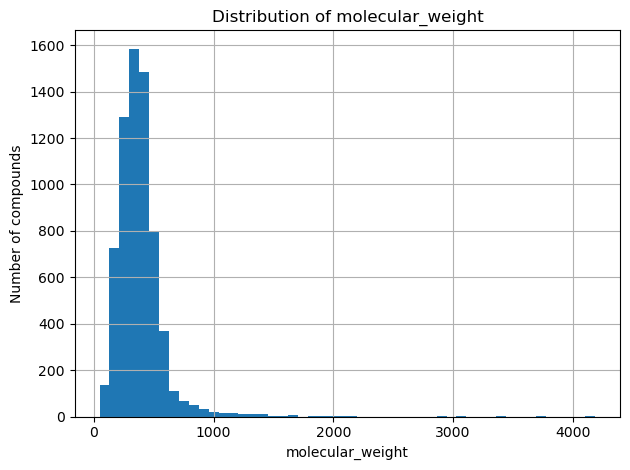

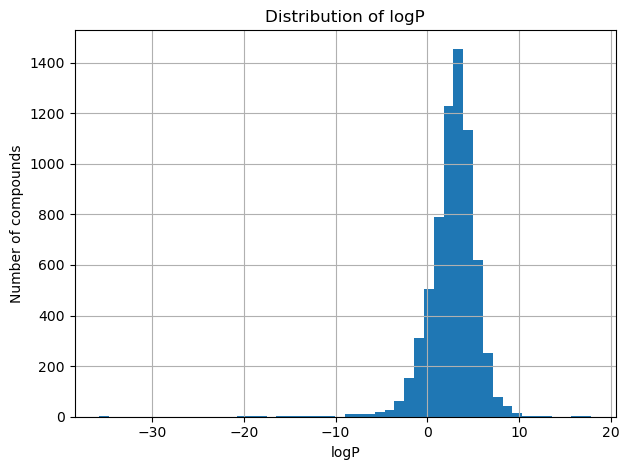

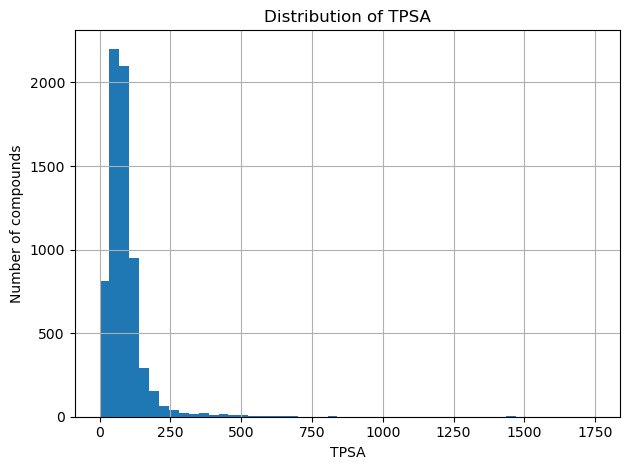

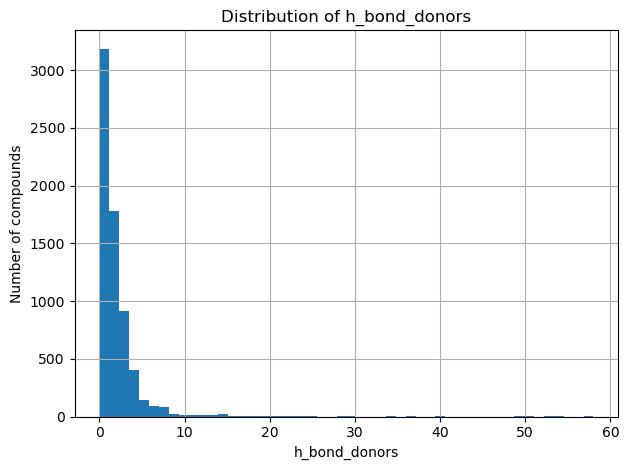

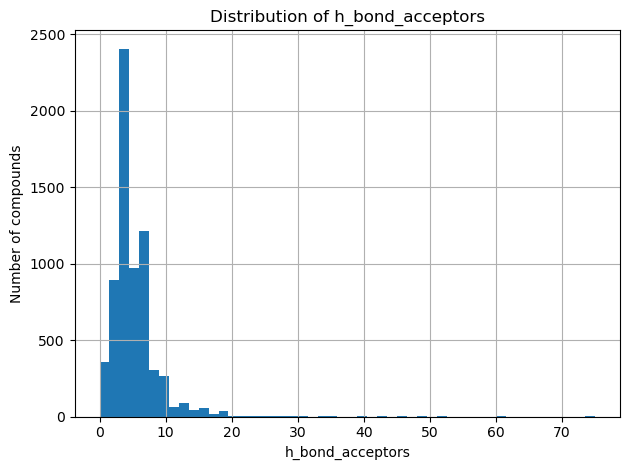

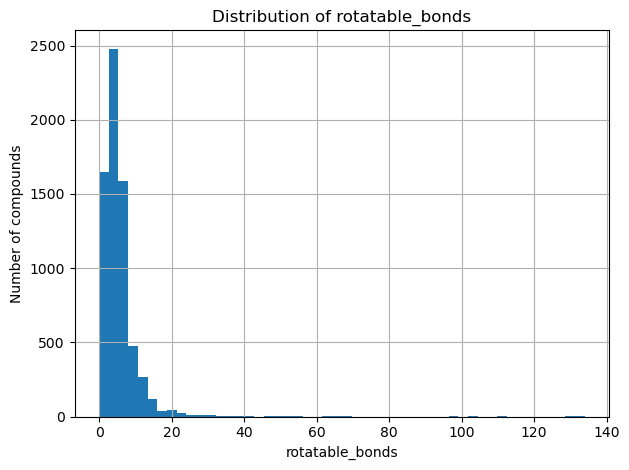

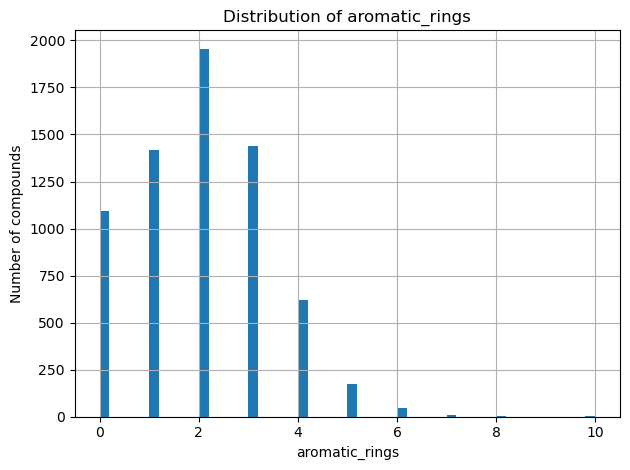

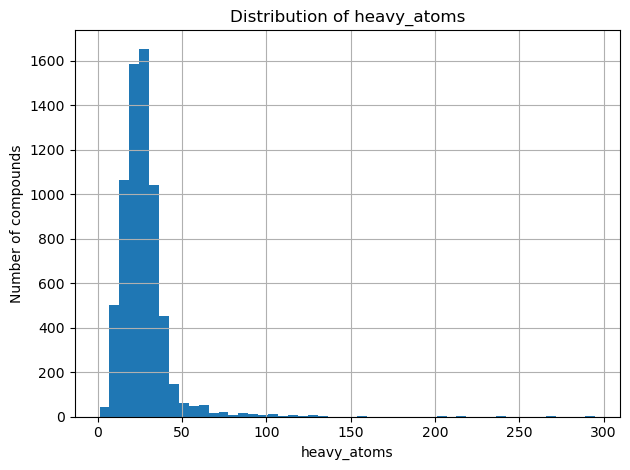

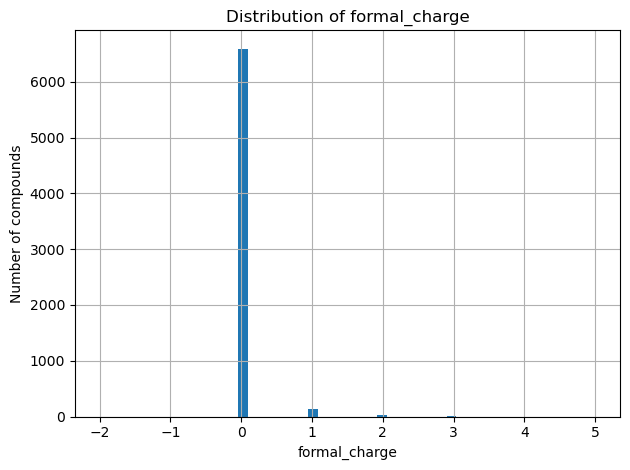

Saved descriptor distribution plots to: /Users/mell/predicting-predictability/figures


In [40]:
import matplotlib.pyplot as plt

for col in descriptor_cols:
    plt.figure()
    descriptors_df[col].dropna().hist(bins=50)
    plt.xlabel(col)
    plt.ylabel("Number of compounds")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    
    output_path = figures_dir / f"distribution_{col}.png"
    plt.savefig(output_path, dpi=300)
    plt.show()

print("Saved descriptor distribution plots to:", figures_dir)

In [41]:
# Compare fingerprint-based chemical similarity

In [42]:
# FIRST load fingerprint representation tables

In [43]:
from pathlib import Path
import pandas as pd

data_dir = Path.home() / "predicting-predictability" / "data"

morgan_df = pd.read_csv(data_dir / "perturbseqr_morgan_fingerprints.csv")
maccs_df = pd.read_csv(data_dir / "perturbseqr_maccs_keys.csv")
cactvs_df = pd.read_csv(data_dir / "perturbseqr_cactvs_pubchem_fingerprints.csv")

print("Morgan:", morgan_df.shape)
print("MACCS:", maccs_df.shape)
print("CACTVS/PubChem:", cactvs_df.shape)

Morgan: (6754, 2060)
MACCS: (6754, 179)
CACTVS/PubChem: (6409, 893)


In [44]:
# SECOND Check columns that identify compounds

In [45]:
print(morgan_df.columns[:20].tolist())
print(maccs_df.columns[:20].tolist())
print(cactvs_df.columns[:20].tolist())

['record_id', 'name', 'pubchem_cid', 'inchi_key', 'smiles', 'broad_id', 'moa', 'target', 'clinical_phase', 'disease_area', 'indication', 'fda_approved', 'morgan_0', 'morgan_1', 'morgan_2', 'morgan_3', 'morgan_4', 'morgan_5', 'morgan_6', 'morgan_7']
['record_id', 'name', 'pubchem_cid', 'inchi_key', 'smiles', 'broad_id', 'moa', 'target', 'clinical_phase', 'disease_area', 'indication', 'fda_approved', 'maccs_0', 'maccs_1', 'maccs_2', 'maccs_3', 'maccs_4', 'maccs_5', 'maccs_6', 'maccs_7']
['name', 'pubchem_cid', 'inchi_key', 'smiles', 'broad_id', 'moa', 'target', 'clinical_phase', 'disease_area', 'indication', 'fda_approved', 'cactvs_pubchem_fp', 'cactvs_0', 'cactvs_1', 'cactvs_2', 'cactvs_3', 'cactvs_4', 'cactvs_5', 'cactvs_6', 'cactvs_7']


In [47]:
# THIRD Keep only compounds found in all three fingerprint tables

In [48]:
ID_COL = "pubchem_cid"

common_ids = set(morgan_df[ID_COL]) & set(maccs_df[ID_COL]) & set(cactvs_df[ID_COL])

print("Compounds shared across all three fingerprint tables:", len(common_ids))

morgan_common = morgan_df[morgan_df[ID_COL].isin(common_ids)].copy()
maccs_common = maccs_df[maccs_df[ID_COL].isin(common_ids)].copy()
cactvs_common = cactvs_df[cactvs_df[ID_COL].isin(common_ids)].copy()

Compounds shared across all three fingerprint tables: 6373


In [49]:
# FOURTH Sort all three tables by the same compound identifier so rows match

In [50]:
morgan_common = morgan_common.sort_values(ID_COL).reset_index(drop=True)
maccs_common = maccs_common.sort_values(ID_COL).reset_index(drop=True)
cactvs_common = cactvs_common.sort_values(ID_COL).reset_index(drop=True)

# Confirm that rows are aligned
print((morgan_common[ID_COL].values == maccs_common[ID_COL].values).all())
print((morgan_common[ID_COL].values == cactvs_common[ID_COL].values).all())

True
True


In [52]:
# FIFTH Identify fingerprint bit columns for each representation

In [53]:
morgan_cols = [col for col in morgan_common.columns if col.startswith("morgan_")]
maccs_cols = [col for col in maccs_common.columns if col.startswith("maccs_")]
cactvs_cols = [col for col in cactvs_common.columns if col.startswith("cactvs_")]

print("Morgan bit columns:", len(morgan_cols))
print("MACCS bit columns:", len(maccs_cols))
print("CACTVS/PubChem bit columns:", len(cactvs_cols))

Morgan bit columns: 2048
MACCS bit columns: 167
CACTVS/PubChem bit columns: 882


In [54]:
# SIXTH Sample a manageable number of compounds for pairwise similarity comparison

In [55]:
sample_size = 500

sample_ids = (
    pd.Series(list(common_ids))
    .sample(n=sample_size, random_state=42)
    .tolist()
)

morgan_sample = morgan_common[morgan_common[ID_COL].isin(sample_ids)].sort_values(ID_COL).reset_index(drop=True)
maccs_sample = maccs_common[maccs_common[ID_COL].isin(sample_ids)].sort_values(ID_COL).reset_index(drop=True)
cactvs_sample = cactvs_common[cactvs_common[ID_COL].isin(sample_ids)].sort_values(ID_COL).reset_index(drop=True)

print(morgan_sample.shape)
print(maccs_sample.shape)
print(cactvs_sample.shape)

(505, 2060)
(505, 179)
(505, 893)


In [56]:
# SEVENTH Define Tanimoto similarity for binary fingerprint vectors

In [57]:
import numpy as np

def tanimoto_similarity(fp1, fp2):
    """
    Calculate Tanimoto similarity between two binary fingerprint vectors.
    """
    fp1 = np.asarray(fp1, dtype=bool)
    fp2 = np.asarray(fp2, dtype=bool)
    
    intersection = np.logical_and(fp1, fp2).sum()
    union = np.logical_or(fp1, fp2).sum()
    
    if union == 0:
        return np.nan
    
    return intersection / union

In [58]:
# Calculate pairwise Tanimoto similarities for the same compound pairs across Morgan, MACCS, and CACTVS/PubChem

In [59]:
morgan_matrix = morgan_sample[morgan_cols].values
maccs_matrix = maccs_sample[maccs_cols].values
cactvs_matrix = cactvs_sample[cactvs_cols].values

pairwise_rows = []

n = len(morgan_sample)

for i in range(n):
    for j in range(i + 1, n):
        pairwise_rows.append({
            "compound_1": morgan_sample.loc[i, "name"],
            "compound_2": morgan_sample.loc[j, "name"],
            "pubchem_cid_1": morgan_sample.loc[i, ID_COL],
            "pubchem_cid_2": morgan_sample.loc[j, ID_COL],
            "morgan_tanimoto": tanimoto_similarity(morgan_matrix[i], morgan_matrix[j]),
            "maccs_tanimoto": tanimoto_similarity(maccs_matrix[i], maccs_matrix[j]),
            "cactvs_pubchem_tanimoto": tanimoto_similarity(cactvs_matrix[i], cactvs_matrix[j])
        })

similarity_comparison_df = pd.DataFrame(pairwise_rows)

print(similarity_comparison_df.shape)
similarity_comparison_df.head()

(127260, 7)


,compound_1,compound_2,pubchem_cid_1,pubchem_cid_2,morgan_tanimoto,maccs_tanimoto,cactvs_pubchem_tanimoto
0,agmatine,histamine,199.0,774.0,0.111111,0.472222,0.268041
1,agmatine,hypoxanthine,199.0,790.0,0.026316,0.113208,0.209524
2,agmatine,orotic-acid,199.0,967.0,0.025641,0.145455,0.242857
3,agmatine,zopolrestat,199.0,1613.0,0.028571,0.133333,0.095000
4,agmatine,oxyquinoline,199.0,1923.0,0.025641,0.045455,0.100592


In [60]:
# Summarize Tanimoto similarity distributions across fingerprint types

In [61]:
similarity_summary = similarity_comparison_df[
    ["morgan_tanimoto", "maccs_tanimoto", "cactvs_pubchem_tanimoto"]
].describe()

similarity_summary

,morgan_tanimoto,maccs_tanimoto,cactvs_pubchem_tanimoto
count,127260.000000,127260.000000,127260.000000
mean,0.098748,0.325917,0.373740
std,0.044266,0.130512,0.149092
min,0.000000,0.000000,0.044693
25%,0.069767,0.229730,0.255682
50%,0.095238,0.318182,0.380597
75%,0.122807,0.415385,0.482759
max,1.000000,1.000000,1.000000


In [62]:
# Save fingerprint similarity summary statistics

In [63]:
summary_path = data_dir / "fingerprint_similarity_summary.csv"

similarity_summary.to_csv(summary_path)

print("Saved to:", summary_path)

Saved to: /Users/mell/predicting-predictability/data/fingerprint_similarity_summary.csv


In [64]:
# Calculate correlations between similarity scores from different fingerprint representations

In [65]:
similarity_correlations = similarity_comparison_df[
    ["morgan_tanimoto", "maccs_tanimoto", "cactvs_pubchem_tanimoto"]
].corr()

similarity_correlations

,morgan_tanimoto,maccs_tanimoto,cactvs_pubchem_tanimoto
morgan_tanimoto,1.000000,0.526163,0.601630
maccs_tanimoto,0.526163,1.000000,0.581866
cactvs_pubchem_tanimoto,0.601630,0.581866,1.000000


In [66]:
# Save fingerprint similarity correlation matrix

In [67]:
correlation_path = data_dir / "fingerprint_similarity_correlations.csv"

similarity_correlations.to_csv(correlation_path)

print("Saved to:", correlation_path)

Saved to: /Users/mell/predicting-predictability/data/fingerprint_similarity_correlations.csv


In [68]:
# Save pairwise fingerprint similarity comparison table

In [69]:
pairwise_path = data_dir / "fingerprint_similarity_pairwise_sample.csv"

similarity_comparison_df.to_csv(pairwise_path, index=False)

print("Saved to:", pairwise_path)

Saved to: /Users/mell/predicting-predictability/data/fingerprint_similarity_pairwise_sample.csv


In [1]:
# Analyze fingerprint similarity results

In [2]:
from pathlib import Path
import pandas as pd

data_dir = Path.home() / "predicting-predictability" / "data"

pairwise_df = pd.read_csv(data_dir / "fingerprint_similarity_pairwise_sample.csv")
similarity_summary = pd.read_csv(data_dir / "fingerprint_similarity_summary.csv", index_col=0)
similarity_correlations = pd.read_csv(data_dir / "fingerprint_similarity_correlations.csv", index_col=0)

print("Pairwise table:", pairwise_df.shape)

display(similarity_summary)
display(similarity_correlations)

Pairwise table: (127260, 7)


,morgan_tanimoto,maccs_tanimoto,cactvs_pubchem_tanimoto
count,127260.000000,127260.000000,127260.000000
mean,0.098748,0.325917,0.373740
std,0.044266,0.130512,0.149092
min,0.000000,0.000000,0.044693
25%,0.069767,0.229730,0.255682
50%,0.095238,0.318182,0.380597
75%,0.122807,0.415385,0.482759
max,1.000000,1.000000,1.000000


,morgan_tanimoto,maccs_tanimoto,cactvs_pubchem_tanimoto
morgan_tanimoto,1.000000,0.526163,0.601630
maccs_tanimoto,0.526163,1.000000,0.581866
cactvs_pubchem_tanimoto,0.601630,0.581866,1.000000


In [3]:
# (d) Visualizing molecular representation space

In [4]:
## PCA visualization of each molecular representation

In [5]:
# Load molecular representation tables for visualization

In [6]:
from pathlib import Path
import pandas as pd

data_dir = Path.home() / "predicting-predictability" / "data"
figures_dir = Path.home() / "predicting-predictability" / "figures"

figures_dir.mkdir(exist_ok=True)

morgan_df = pd.read_csv(data_dir / "perturbseqr_morgan_fingerprints.csv")
maccs_df = pd.read_csv(data_dir / "perturbseqr_maccs_keys.csv")
cactvs_df = pd.read_csv(data_dir / "perturbseqr_cactvs_pubchem_fingerprints.csv")
descriptors_df = pd.read_csv(data_dir / "perturbseqr_molecular_descriptors.csv")

print("Morgan:", morgan_df.shape)
print("MACCS:", maccs_df.shape)
print("CACTVS/PubChem:", cactvs_df.shape)
print("Descriptors:", descriptors_df.shape)

Morgan: (6754, 2060)
MACCS: (6754, 179)
CACTVS/PubChem: (6409, 893)
Descriptors: (6754, 21)


In [7]:
# Identify feature columns for each molecular representation

In [8]:
morgan_cols = [col for col in morgan_df.columns if col.startswith("morgan_")]
maccs_cols = [col for col in maccs_df.columns if col.startswith("maccs_")]
cactvs_cols = [col for col in cactvs_df.columns if col.startswith("cactvs_")]

descriptor_cols = [
    "molecular_weight",
    "logP",
    "TPSA",
    "h_bond_donors",
    "h_bond_acceptors",
    "rotatable_bonds",
    "aromatic_rings",
    "heavy_atoms",
    "formal_charge"
]

print("Morgan features:", len(morgan_cols))
print("MACCS features:", len(maccs_cols))
print("CACTVS features:", len(cactvs_cols))
print("Descriptor features:", len(descriptor_cols))

Morgan features: 2048
MACCS features: 167
CACTVS features: 882
Descriptor features: 9


In [9]:
# Define a reusable PCA plotting function

In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

def make_pca_plot(df, feature_cols, representation_name, output_filename, scale_features=False):
    """
    Create a 2D PCA plot for a molecular representation table.
    Each point represents one compound.
    """
    plot_df = df.dropna(subset=feature_cols).copy()
    X = plot_df[feature_cols].values
    
    if scale_features:
        X = StandardScaler().fit_transform(X)
    
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X)
    
    pca_df = pd.DataFrame({
        "name": plot_df["name"].values,
        "pubchem_cid": plot_df["pubchem_cid"].values,
        "PC1": X_pca[:, 0],
        "PC2": X_pca[:, 1]
    })
    
    plt.figure(figsize=(7, 5))
    plt.scatter(pca_df["PC1"], pca_df["PC2"], s=10, alpha=0.6)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
    plt.title(f"PCA of {representation_name}")
    plt.tight_layout()
    
    output_path = figures_dir / output_filename
    plt.savefig(output_path, dpi=300)
    plt.show()
    
    print(f"Saved plot to: {output_path}")
    print("Variance explained by PC1 and PC2:", pca.explained_variance_ratio_)
    
    return pca_df

In [11]:
# PCA plot for Morgan fingerprints

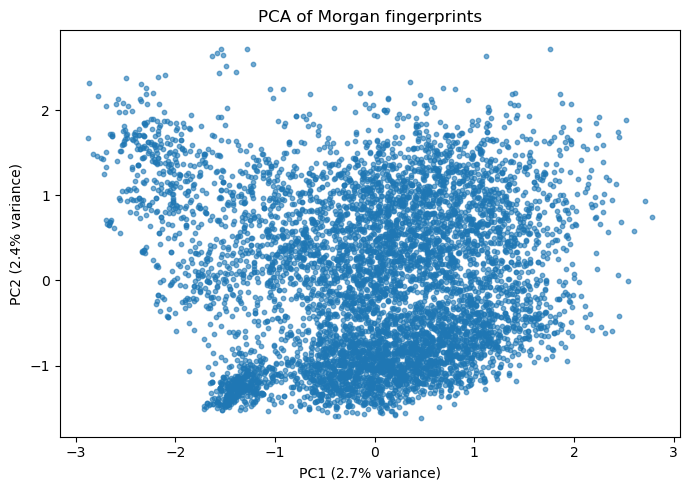

Saved plot to: /Users/mell/predicting-predictability/figures/pca_morgan_fingerprints.png
Variance explained by PC1 and PC2: [0.02698535 0.02352799]


In [12]:
morgan_pca_df = make_pca_plot(
    df=morgan_df,
    feature_cols=morgan_cols,
    representation_name="Morgan fingerprints",
    output_filename="pca_morgan_fingerprints.png",
    scale_features=False
)

In [13]:
# PCA plot for MACCS keys

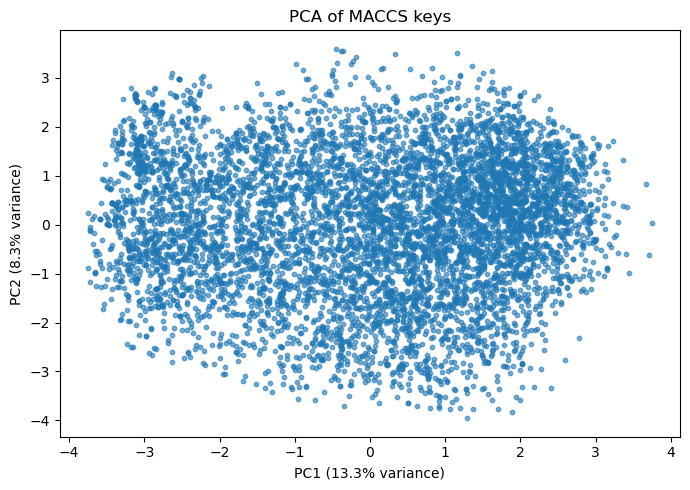

Saved plot to: /Users/mell/predicting-predictability/figures/pca_maccs_keys.png
Variance explained by PC1 and PC2: [0.13301671 0.08320551]


In [14]:
maccs_pca_df = make_pca_plot(
    df=maccs_df,
    feature_cols=maccs_cols,
    representation_name="MACCS keys",
    output_filename="pca_maccs_keys.png",
    scale_features=False
)

In [15]:
# PCA plot for CACTVS/PubChem fingerprints

In [16]:
cactvs_pca_df = make_pca_plot(
    df=cactvs_df,
    feature_cols=cactvs_cols,
    representation_name="CACTVS/PubChem fingerprints",
    output_filename="pca_cactvs_pubchem_fingerprints.png",
    scale_features=False
)

ValueError: Input X contains infinity or a value too large for dtype('float64').

In [17]:
# Fix CACTVS feature columns so only numeric bit columns are included

In [18]:
cactvs_cols = [
    col for col in cactvs_df.columns
    if col.startswith("cactvs_") and col != "cactvs_pubchem_fp"
]

print("Number of CACTVS bit columns:", len(cactvs_cols))
print(cactvs_cols[:5])
print(cactvs_cols[-5:])

Number of CACTVS bit columns: 881
['cactvs_0', 'cactvs_1', 'cactvs_2', 'cactvs_3', 'cactvs_4']
['cactvs_876', 'cactvs_877', 'cactvs_878', 'cactvs_879', 'cactvs_880']


In [20]:
# PCA plot for CACTVS/PubChem fingerprints

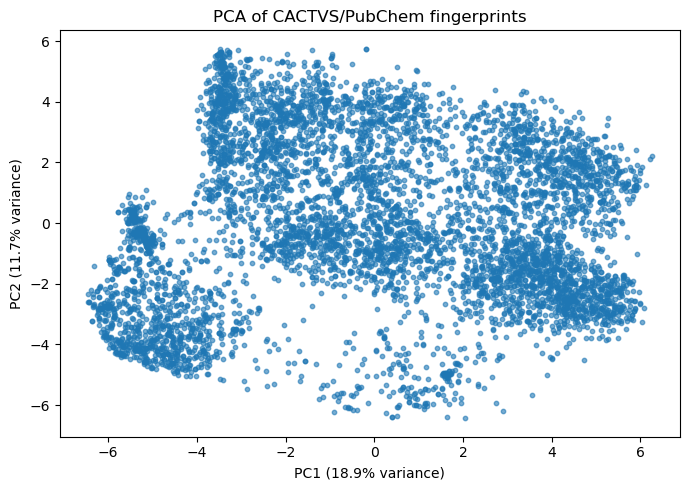

Saved plot to: /Users/mell/predicting-predictability/figures/pca_cactvs_pubchem_fingerprints.png
Variance explained by PC1 and PC2: [0.18858307 0.1166192 ]


In [21]:
cactvs_pca_df = make_pca_plot(
    df=cactvs_df,
    feature_cols=cactvs_cols,
    representation_name="CACTVS/PubChem fingerprints",
    output_filename="pca_cactvs_pubchem_fingerprints.png",
    scale_features=False
)

In [23]:
# PCA plot for molecular descriptors

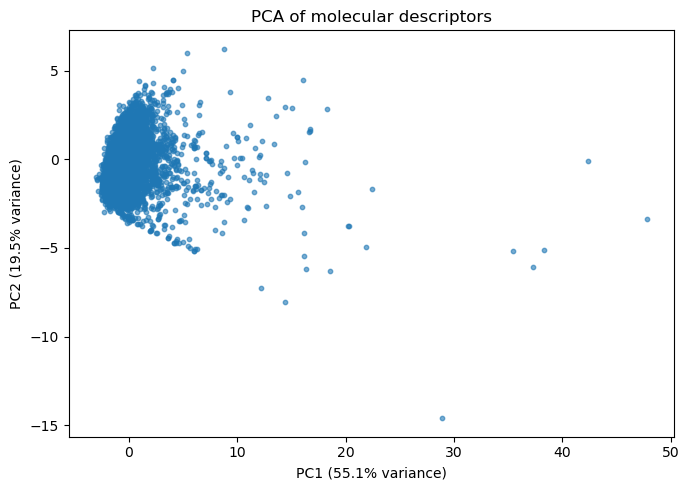

Saved plot to: /Users/mell/predicting-predictability/figures/pca_molecular_descriptors.png
Variance explained by PC1 and PC2: [0.55065773 0.19542565]


In [24]:
descriptors_pca_df = make_pca_plot(
    df=descriptors_df,
    feature_cols=descriptor_cols,
    representation_name="molecular descriptors",
    output_filename="pca_molecular_descriptors.png",
    scale_features=True
)

In [25]:
# Save PCA coordinates for each representation

In [26]:
morgan_pca_df.to_csv(data_dir / "pca_morgan_fingerprints.csv", index=False)
maccs_pca_df.to_csv(data_dir / "pca_maccs_keys.csv", index=False)
cactvs_pca_df.to_csv(data_dir / "pca_cactvs_pubchem_fingerprints.csv", index=False)
descriptors_pca_df.to_csv(data_dir / "pca_molecular_descriptors.csv", index=False)

print("Saved PCA coordinate tables.")

Saved PCA coordinate tables.


In [27]:
import sys
!{sys.executable} -m pip install umap-learn

  Using cached numba-0.65.1-cp314-cp314-macosx_12_0_arm64.whl.metadata (2.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 6.4 MB/s  0:00:00a 0:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 11.8 MB/s  0:00:03 eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [umap-learn] 1/4 [numba]


In [28]:
import umap
print("UMAP works")

UMAP works


In [29]:
# Import UMAP for nonlinear dimensionality reduction

In [30]:
import umap
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

print("UMAP works")

UMAP works


In [31]:
# Define a reusable UMAP plotting function

In [32]:
def make_umap_plot(df, feature_cols, representation_name, output_filename, scale_features=False):
    """
    Create a 2D UMAP plot for a molecular representation table.
    Each point represents one compound.
    """
    plot_df = df.dropna(subset=feature_cols).copy()
    X = plot_df[feature_cols].values
    
    if scale_features:
        X = StandardScaler().fit_transform(X)
    
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.1,
        metric="euclidean",
        random_state=42
    )
    
    X_umap = reducer.fit_transform(X)
    
    umap_df = pd.DataFrame({
        "name": plot_df["name"].values,
        "pubchem_cid": plot_df["pubchem_cid"].values,
        "UMAP1": X_umap[:, 0],
        "UMAP2": X_umap[:, 1]
    })
    
    plt.figure(figsize=(7, 5))
    plt.scatter(umap_df["UMAP1"], umap_df["UMAP2"], s=10, alpha=0.6)
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.title(f"UMAP of {representation_name}")
    plt.tight_layout()
    
    output_path = figures_dir / output_filename
    plt.savefig(output_path, dpi=300)
    plt.show()
    
    print(f"Saved plot to: {output_path}")
    
    return umap_df

In [33]:
# UMAP plot for Morgan fingerprints

/opt/miniconda3/envs/my-rdkit-env/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


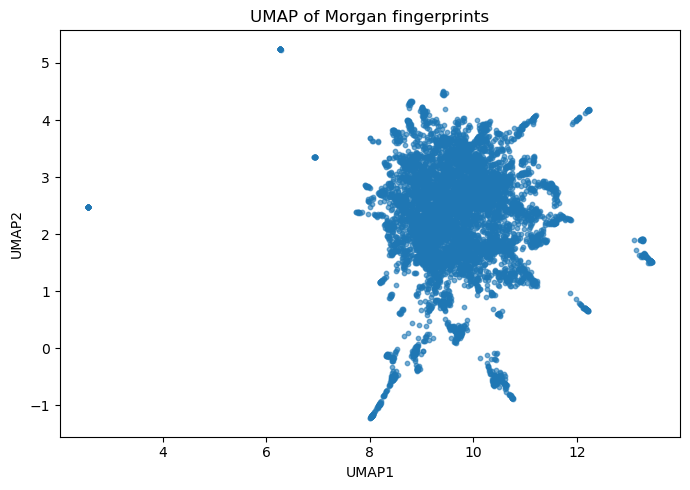

Saved plot to: /Users/mell/predicting-predictability/figures/umap_morgan_fingerprints.png


In [34]:
morgan_umap_df = make_umap_plot(
    df=morgan_df,
    feature_cols=morgan_cols,
    representation_name="Morgan fingerprints",
    output_filename="umap_morgan_fingerprints.png",
    scale_features=False
)

In [35]:
# UMAP plot for MACCS keys

/opt/miniconda3/envs/my-rdkit-env/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


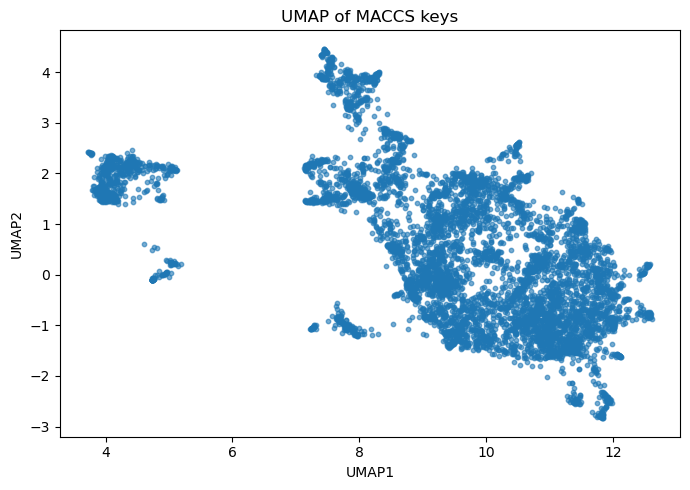

Saved plot to: /Users/mell/predicting-predictability/figures/umap_maccs_keys.png


In [36]:
maccs_umap_df = make_umap_plot(
    df=maccs_df,
    feature_cols=maccs_cols,
    representation_name="MACCS keys",
    output_filename="umap_maccs_keys.png",
    scale_features=False
)

In [37]:
# Make sure CACTVS columns only include numeric bit columns

In [38]:
cactvs_cols = [
    col for col in cactvs_df.columns
    if col.startswith("cactvs_") and col != "cactvs_pubchem_fp"
]

print("CACTVS bit columns:", len(cactvs_cols))

CACTVS bit columns: 881


In [40]:
# UMAP plot for CACTVS/PubChem fingerprints

/opt/miniconda3/envs/my-rdkit-env/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


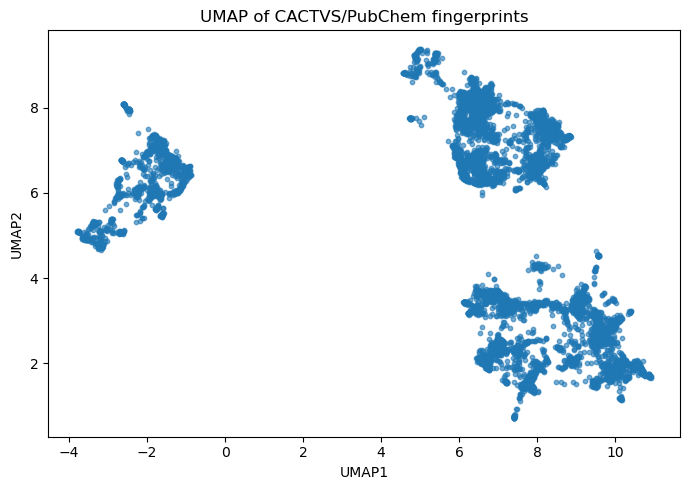

Saved plot to: /Users/mell/predicting-predictability/figures/umap_cactvs_pubchem_fingerprints.png


In [41]:
cactvs_umap_df = make_umap_plot(
    df=cactvs_df,
    feature_cols=cactvs_cols,
    representation_name="CACTVS/PubChem fingerprints",
    output_filename="umap_cactvs_pubchem_fingerprints.png",
    scale_features=False
)

In [42]:
# UMAP plot for molecular descriptors

/opt/miniconda3/envs/my-rdkit-env/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


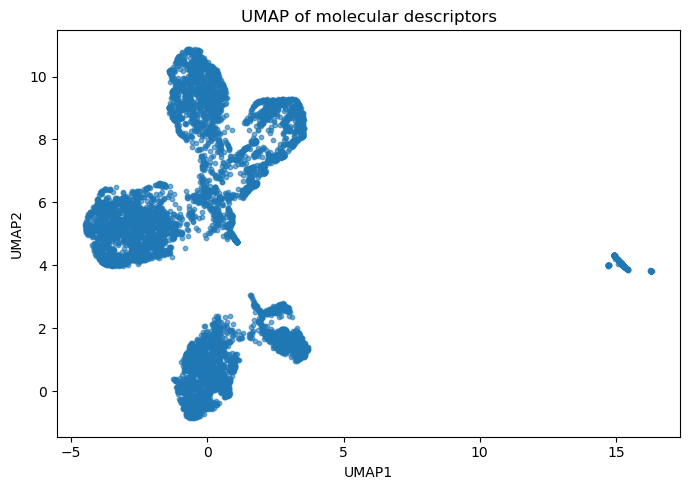

Saved plot to: /Users/mell/predicting-predictability/figures/umap_molecular_descriptors.png


In [43]:
descriptors_umap_df = make_umap_plot(
    df=descriptors_df,
    feature_cols=descriptor_cols,
    representation_name="molecular descriptors",
    output_filename="umap_molecular_descriptors.png",
    scale_features=True
)

In [44]:
# Save UMAP coordinate tables
morgan_umap_df.to_csv(data_dir / "umap_morgan_fingerprints.csv", index=False)
maccs_umap_df.to_csv(data_dir / "umap_maccs_keys.csv", index=False)
cactvs_umap_df.to_csv(data_dir / "umap_cactvs_pubchem_fingerprints.csv", index=False)
descriptors_umap_df.to_csv(data_dir / "umap_molecular_descriptors.csv", index=False)

print("Saved UMAP coordinate tables.")

Saved UMAP coordinate tables.


In [4]:
import os

print(os.listdir("data"))

FileNotFoundError: [Errno 2] No such file or directory: 'data'

In [5]:
import os
print(os.getcwd())

/Users/mell/predicting-predictability/notebooks


In [6]:
print(os.listdir())

['objective_2_rdkit_fingerprints.ipynb', '.ipynb_checkpoints']


In [7]:
import os

print(os.listdir(".."))

['README.md', '.gitignore', 'figures', 'scripts', '.ipynb_checkpoints', '.git', 'data', 'notebooks']


In [8]:
print(os.listdir("../data"))

['perturbseqr_morgan_fingerprints.csv', 'umap_morgan_fingerprints.csv', 'pca_morgan_fingerprints.csv', 'umap_maccs_keys.csv', 'representation_comparison_summary.csv', 'pca_molecular_descriptors.csv', 'perturbseqr_molecular_descriptors.csv', 'perturbseqr_cactvs_pubchem_fingerprints.csv', 'fingerprint_similarity_correlations.csv', 'example_morgan_fingerprints.csv', 'descriptor_summary_statistics.csv', 'pca_maccs_keys.csv', 'fingerprint_similarity_summary.csv', 'pca_cactvs_pubchem_fingerprints.csv', 'umap_cactvs_pubchem_fingerprints.csv', 'umap_molecular_descriptors.csv', 'fingerprint_similarity_pairwise_sample.csv', 'perturbseqr_maccs_keys.csv', 'drug_master.json']


In [9]:
morgan_umap_df = pd.read_csv("../data/umap_morgan_fingerprints.csv")

NameError: name 'pd' is not defined

In [10]:
import pandas as pd

In [11]:
morgan_umap_df = pd.read_csv("../data/umap_morgan_fingerprints.csv")

In [12]:
morgan_umap_df.head()

,name,pubchem_cid,UMAP1,UMAP2
0,be-2254,86308637.0,9.513340,2.629315
1,tasimelteon,10220503.0,9.782667,2.093299
2,esaxerenone,25052023.0,9.814395,3.465860
3,ixazomib-citrate,69040311.0,10.552727,2.296723
4,alendronate,44400013.0,9.950693,1.426218


In [13]:
metadata_df = pd.read_json("../data/drug_master.json")

In [14]:
metadata_df.head()

,be-2254,tasimelteon,esaxerenone,ixazomib-citrate,alendronate,dazmegrel,nobiletin,azd7986,bebt-908,nitromide,...,troclosene,siremadlin,racecadotril,80841-78-7,fli-06,somantadine,fosphenytoin,cpsi-1306-(+/-),d-alpha-tocopheryl-succinate,ribociclib
name,be-2254,tasimelteon,esaxerenone,ixazomib-citrate,alendronate,dazmegrel,nobiletin,azd7986,bebt-908,nitromide,...,troclosene,siremadlin,racecadotril,80841-78-7,fli-06,somantadine,fosphenytoin,cpsi-1306-(+/-),d-alpha-tocopheryl-succinate,ribociclib
pubchem_cid,86308637,10220503,25052023,69040311,44400013,53555,72344,118253852,59474330,4511,...,16726,71678098,60561,9855518,6966819,50234,56339,52936269,20353,44631912
inchi_key,PZZOEXPDTYIBPI-MRXNPFEDSA-N,PTOIAAWZLUQTIO-GXFFZTMASA-N,NOSNHVJANRODGR-UHFFFAOYSA-N,YTXSYWAKVMZICI-VBKZILBWSA-N,OGSPWJRAVKPPFI-UHFFFAOYSA-N,DEQLGSOHGTZKFB-UHFFFAOYSA-N,MRIAQLRQZPPODS-UHFFFAOYSA-N,AEXFXNFMSAAELR-RXVVDRJESA-N,TWJZFXHSPBBPNI-UHFFFAOYSA-N,UUKWKUSGGZNXGA-UHFFFAOYSA-N,...,CEJLBZWIKQJOAT-UHFFFAOYSA-N,AGBSXNCBIWWLHD-FQEVSTJZSA-N,ODUOJXZPIYUATO-LJQANCHMSA-N,QCLFSYYUWPUWQR-UHFFFAOYSA-N,DUGBYNJMBYPWGS-FOIFJWKZSA-N,OWKXRDQRMTVCEX-UHFFFAOYSA-N,XWLUWCNOOVRFPX-UHFFFAOYSA-N,GUWOSEVHCSNYFK-LLVKDONJSA-N,IELOKBJPULMYRW-NJQVLOCASA-N,RHXHGRAEPCAFML-UHFFFAOYSA-N
smiles,Oc1ccc(CCNC[C@H]2CCc3ccccc3C2=O)cc1 |r|,CCC(=O)NC[C@@H]1C[C@H]1c1cccc2OCCc12,Cc1c(cn(CCO)c1-c1ccccc1C(F)(F)F)C(=O)Nc1ccc(cc...,CC(C)C[C@H](NC(=O)CNC(=O)c1cc(Cl)ccc1Cl)B1OC(=...,NCCCC(O)(P(O)(O)=O)P(O)(O)=O,Cc1c(Cn2ccnc2)c2ccccc2n1CCC(O)=O,COc1ccc(cc1OC)-c1cc(=O)c2c(OC)c(OC)c(OC)c(OC)c2o1,Cn1c2cc(ccc2oc1=O)-c1ccc(C[C@H](NC(=O)[C@@H]2C...,CNc1ccc(cn1)-c1nc(N2CCOCC2)c2sc(CN(C)c3ncc(cn3...,NC(=O)c1cc(cc(c1)[N+]([O-])=O)[N+]([O-])=O,...,Cln1c(=O)[nH]c(=O)n(Cl)c1=O,COc1ncc(-c2nc3C(=O)N([C@H](c3n2C(C)C)c2ccc(Cl)...,CC(=O)SC[C@@H](Cc1ccccc1)C(=O)NCC(=O)OCc1ccccc...,Cc1oc(=O)oc1CCl,CC1=NC2=C([C@@H](C1C(=O)OC1CCCCC1)c1ccc(cc1)[N...,CC(C)(N)CC12CC3CC(CC(C3)C1)C2,OP(O)(=O)OCN1C(=O)NC(C1=O)(c1ccccc1)c1ccccc1,Fc1ccc(C2=NO[C@@H](CC(=O)N3CCOCC3)C2)c(F)c1 |&...,CC(C)CCC[C@@H](C)CCC[C@@H](C)CCC[C@]1(C)CCc2c(...,CN(C)C(=O)c1cc2cnc(Nc3ccc(cn3)N3CCNCC3)nc2n1C1...
broad_id,BRD-A24429032-003-03-2,BRD-K62971431-001-01-9,BRD-K00003374-001-01-9,BRD-A66419424-001-02-4,BRD-K75527158-360-05-6,BRD-K20738689-001-01-2,BRD-K06753942-001-14-5,BRD-K00003398-001-01-9,BRD-K00003291-001-01-9,BRD-K76381435-001-09-9,...,BRD-K76375510-237-01-1,BRD-K65480835-001-02-9,BRD-A08187463-001-12-9,BRD-K03044000-001-01-8,BRD-A44500574-001-04-9,BRD-K85764479-003-01-0,BRD-K53809807-304-02-4,BRD-A81603255-001-02-9,BRD-K64636206-001-02-7,BRD-K36788280-001-04-6


In [15]:
metadata_df = metadata_df.T

In [16]:
metadata_df.head()

,name,pubchem_cid,inchi_key,smiles,broad_id,moa,target,clinical_phase,disease_area,indication,fda_approved
be-2254,be-2254,86308637,PZZOEXPDTYIBPI-MRXNPFEDSA-N,Oc1ccc(CCNC[C@H]2CCc3ccccc3C2=O)cc1 |r|,BRD-A24429032-003-03-2,adrenergic receptor antagonist,ADRA1A,Phase 2,,,False
tasimelteon,tasimelteon,10220503,PTOIAAWZLUQTIO-GXFFZTMASA-N,CCC(=O)NC[C@@H]1C[C@H]1c1cccc2OCCc12,BRD-K62971431-001-01-9,melatonin receptor agonist,MTNR1A|MTNR1B,Launched,neurology/psychiatry,Non-24-Hour Sleep-Wake Disorder,True
esaxerenone,esaxerenone,25052023,NOSNHVJANRODGR-UHFFFAOYSA-N,Cc1c(cn(CCO)c1-c1ccccc1C(F)(F)F)C(=O)Nc1ccc(cc...,BRD-K00003374-001-01-9,mineralocorticoid receptor antagonist,,Preclinical,,,False
ixazomib-citrate,ixazomib-citrate,69040311,YTXSYWAKVMZICI-VBKZILBWSA-N,CC(C)C[C@H](NC(=O)CNC(=O)c1cc(Cl)ccc1Cl)B1OC(=...,BRD-A66419424-001-02-4,proteasome inhibitor,,Launched,hematologic malignancy,multiple myeloma,True
alendronate,alendronate,44400013,OGSPWJRAVKPPFI-UHFFFAOYSA-N,NCCCC(O)(P(O)(O)=O)P(O)(O)=O,BRD-K75527158-360-05-6,bone resorption inhibitor,ATP6V1A|FDPS|PTPN4|PTPRE|PTPRS,Launched,orthopedics,osteoporosis,True


In [17]:
metadata_df.columns.tolist()

['name',
 'pubchem_cid',
 'inchi_key',
 'smiles',
 'broad_id',
 'moa',
 'target',
 'clinical_phase',
 'disease_area',
 'indication',
 'fda_approved']

In [18]:
metadata_df["moa"].value_counts().head(20)

moa
                                           569
adrenergic receptor antagonist             104
cyclooxygenase inhibitor                   104
bacterial cell wall synthesis inhibitor     96
acetylcholine receptor antagonist           87
adrenergic receptor agonist                 85
glutamate receptor antagonist               79
histamine receptor antagonist               78
serotonin receptor antagonist               77
phosphodiesterase inhibitor                 75
dopamine receptor antagonist                71
serotonin receptor agonist                  66
PI3K inhibitor                              51
calcium channel blocker                     50
glucocorticoid receptor agonist             47
HDAC inhibitor                              46
sodium channel blocker                      44
EGFR inhibitor                              44
topoisomerase inhibitor                     44
acetylcholine receptor agonist              43
Name: count, dtype: int64

In [19]:
morgan_plot_df = morgan_umap_df.merge(
    metadata_df,
    on="name",
    how="left"
)

In [20]:
morgan_plot_df.head()

,name,pubchem_cid_x,UMAP1,UMAP2,pubchem_cid_y,inchi_key,smiles,broad_id,moa,target,clinical_phase,disease_area,indication,fda_approved
0,be-2254,86308637.0,9.513340,2.629315,86308637,PZZOEXPDTYIBPI-MRXNPFEDSA-N,Oc1ccc(CCNC[C@H]2CCc3ccccc3C2=O)cc1 |r|,BRD-A24429032-003-03-2,adrenergic receptor antagonist,ADRA1A,Phase 2,,,False
1,tasimelteon,10220503.0,9.782667,2.093299,10220503,PTOIAAWZLUQTIO-GXFFZTMASA-N,CCC(=O)NC[C@@H]1C[C@H]1c1cccc2OCCc12,BRD-K62971431-001-01-9,melatonin receptor agonist,MTNR1A|MTNR1B,Launched,neurology/psychiatry,Non-24-Hour Sleep-Wake Disorder,True
2,esaxerenone,25052023.0,9.814395,3.465860,25052023,NOSNHVJANRODGR-UHFFFAOYSA-N,Cc1c(cn(CCO)c1-c1ccccc1C(F)(F)F)C(=O)Nc1ccc(cc...,BRD-K00003374-001-01-9,mineralocorticoid receptor antagonist,,Preclinical,,,False
3,ixazomib-citrate,69040311.0,10.552727,2.296723,69040311,YTXSYWAKVMZICI-VBKZILBWSA-N,CC(C)C[C@H](NC(=O)CNC(=O)c1cc(Cl)ccc1Cl)B1OC(=...,BRD-A66419424-001-02-4,proteasome inhibitor,,Launched,hematologic malignancy,multiple myeloma,True
4,alendronate,44400013.0,9.950693,1.426218,44400013,OGSPWJRAVKPPFI-UHFFFAOYSA-N,NCCCC(O)(P(O)(O)=O)P(O)(O)=O,BRD-K75527158-360-05-6,bone resorption inhibitor,ATP6V1A|FDPS|PTPN4|PTPRE|PTPRS,Launched,orthopedics,osteoporosis,True


In [21]:
top10_moas = metadata_df["moa"].value_counts().head(10).index.tolist()

top10_moas

['',
 'adrenergic receptor antagonist',
 'cyclooxygenase inhibitor',
 'bacterial cell wall synthesis inhibitor',
 'acetylcholine receptor antagonist',
 'adrenergic receptor agonist',
 'glutamate receptor antagonist',
 'histamine receptor antagonist',
 'serotonin receptor antagonist',
 'phosphodiesterase inhibitor']

In [22]:
morgan_plot_df.head()

,name,pubchem_cid_x,UMAP1,UMAP2,pubchem_cid_y,inchi_key,smiles,broad_id,moa,target,clinical_phase,disease_area,indication,fda_approved
0,be-2254,86308637.0,9.513340,2.629315,86308637,PZZOEXPDTYIBPI-MRXNPFEDSA-N,Oc1ccc(CCNC[C@H]2CCc3ccccc3C2=O)cc1 |r|,BRD-A24429032-003-03-2,adrenergic receptor antagonist,ADRA1A,Phase 2,,,False
1,tasimelteon,10220503.0,9.782667,2.093299,10220503,PTOIAAWZLUQTIO-GXFFZTMASA-N,CCC(=O)NC[C@@H]1C[C@H]1c1cccc2OCCc12,BRD-K62971431-001-01-9,melatonin receptor agonist,MTNR1A|MTNR1B,Launched,neurology/psychiatry,Non-24-Hour Sleep-Wake Disorder,True
2,esaxerenone,25052023.0,9.814395,3.465860,25052023,NOSNHVJANRODGR-UHFFFAOYSA-N,Cc1c(cn(CCO)c1-c1ccccc1C(F)(F)F)C(=O)Nc1ccc(cc...,BRD-K00003374-001-01-9,mineralocorticoid receptor antagonist,,Preclinical,,,False
3,ixazomib-citrate,69040311.0,10.552727,2.296723,69040311,YTXSYWAKVMZICI-VBKZILBWSA-N,CC(C)C[C@H](NC(=O)CNC(=O)c1cc(Cl)ccc1Cl)B1OC(=...,BRD-A66419424-001-02-4,proteasome inhibitor,,Launched,hematologic malignancy,multiple myeloma,True
4,alendronate,44400013.0,9.950693,1.426218,44400013,OGSPWJRAVKPPFI-UHFFFAOYSA-N,NCCCC(O)(P(O)(O)=O)P(O)(O)=O,BRD-K75527158-360-05-6,bone resorption inhibitor,ATP6V1A|FDPS|PTPN4|PTPRE|PTPRS,Launched,orthopedics,osteoporosis,True


In [23]:
top10_moas = metadata_df["moa"].value_counts().head(10).index.tolist()

morgan_top10 = morgan_plot_df[
    morgan_plot_df["moa"].isin(top10_moas)
]

print(morgan_top10.shape)

(1339, 14)


In [25]:
import matplotlib.pyplot as plt

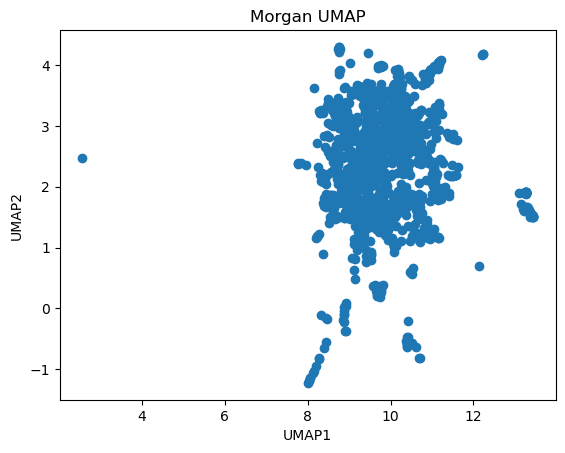

In [26]:
plt.scatter(
    morgan_top10["UMAP1"],
    morgan_top10["UMAP2"]
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Morgan UMAP")
plt.show()

In [27]:
# Make a color-coded UMAP by MoA

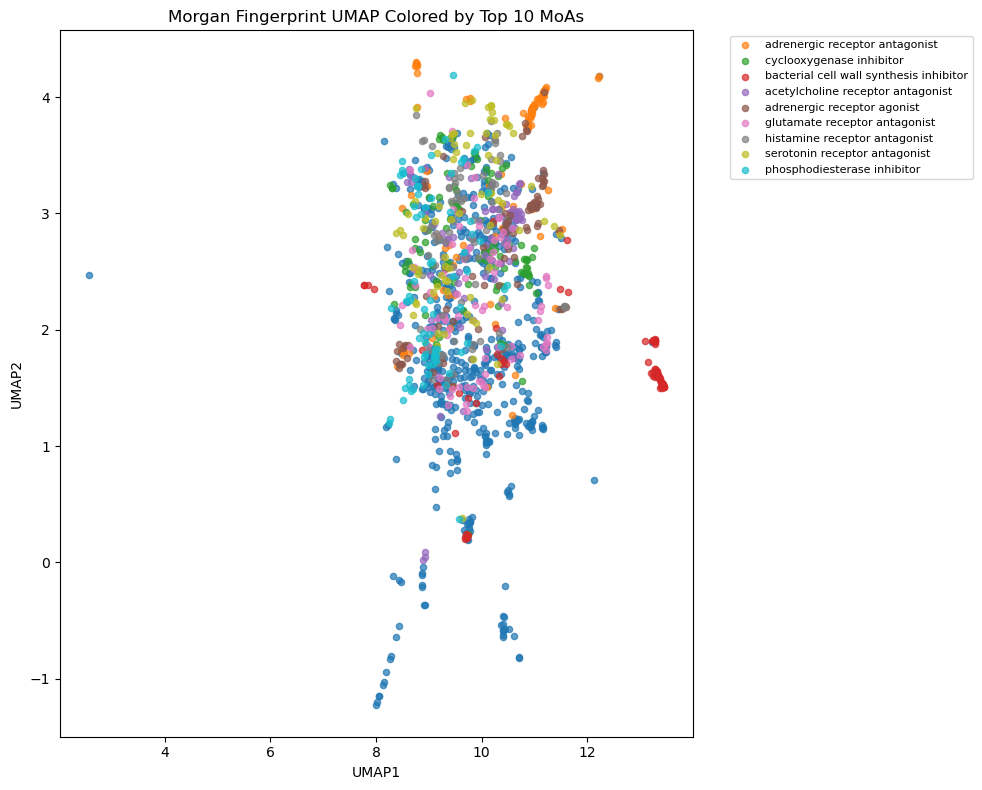

In [28]:
plt.figure(figsize=(10,8))

for moa in top10_moas:
    subset = morgan_top10[morgan_top10["moa"] == moa]

    plt.scatter(
        subset["UMAP1"],
        subset["UMAP2"],
        label=moa,
        alpha=0.7,
        s=20
    )

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Morgan Fingerprint UMAP Colored by Top 10 MoAs")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()
plt.show()

In [29]:
morgan_top10.groupby("moa").size().sort_values(ascending=False)

moa
                                           567
adrenergic receptor antagonist             104
cyclooxygenase inhibitor                   104
bacterial cell wall synthesis inhibitor     95
adrenergic receptor agonist                 84
acetylcholine receptor antagonist           80
glutamate receptor antagonist               79
histamine receptor antagonist               76
phosphodiesterase inhibitor                 75
serotonin receptor antagonist               75
dtype: int64

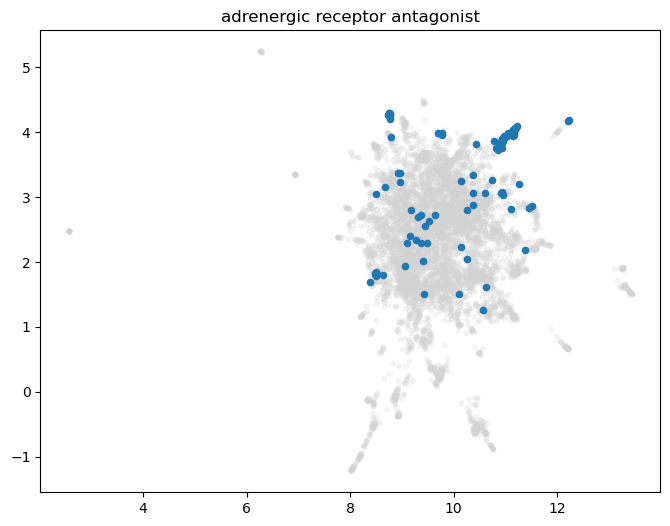

In [30]:
selected_moa = "adrenergic receptor antagonist"

subset = morgan_plot_df.copy()

plt.figure(figsize=(8,6))

plt.scatter(
    subset["UMAP1"],
    subset["UMAP2"],
    color="lightgray",
    alpha=0.2,
    s=10
)

highlight = subset[subset["moa"] == selected_moa]

plt.scatter(
    highlight["UMAP1"],
    highlight["UMAP2"],
    s=20
)

plt.title(selected_moa)
plt.show()

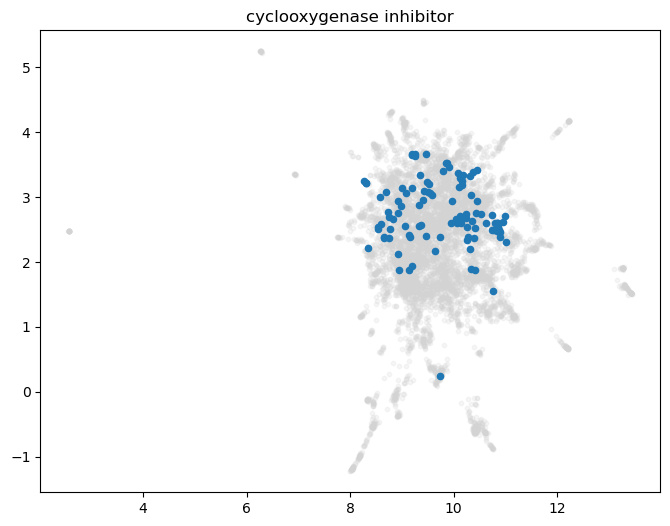

In [31]:
selected_moa = "cyclooxygenase inhibitor"

subset = morgan_plot_df.copy()

plt.figure(figsize=(8,6))

plt.scatter(
    subset["UMAP1"],
    subset["UMAP2"],
    color="lightgray",
    alpha=0.2,
    s=10
)

highlight = subset[subset["moa"] == selected_moa]

plt.scatter(
    highlight["UMAP1"],
    highlight["UMAP2"],
    s=20
)

plt.title(selected_moa)
plt.show()

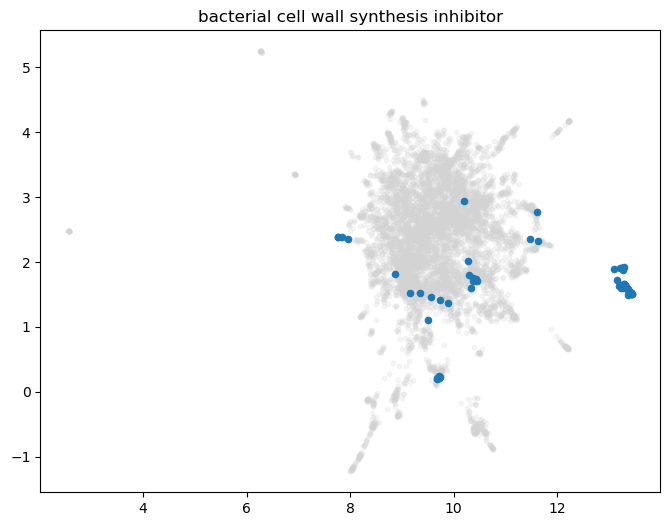

In [32]:
selected_moa = "bacterial cell wall synthesis inhibitor"

subset = morgan_plot_df.copy()

plt.figure(figsize=(8,6))

plt.scatter(
    subset["UMAP1"],
    subset["UMAP2"],
    color="lightgray",
    alpha=0.2,
    s=10
)

highlight = subset[subset["moa"] == selected_moa]

plt.scatter(
    highlight["UMAP1"],
    highlight["UMAP2"],
    s=20
)

plt.title(selected_moa)
plt.show()

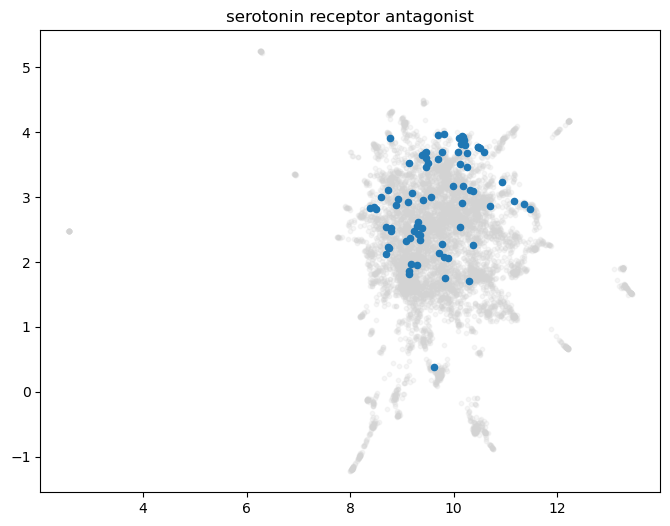

In [33]:
selected_moa = "serotonin receptor antagonist"

subset = morgan_plot_df.copy()

plt.figure(figsize=(8,6))

plt.scatter(
    subset["UMAP1"],
    subset["UMAP2"],
    color="lightgray",
    alpha=0.2,
    s=10
)

highlight = subset[subset["moa"] == selected_moa]

plt.scatter(
    highlight["UMAP1"],
    highlight["UMAP2"],
    s=20
)

plt.title(selected_moa)
plt.show()

In [34]:
maccs_umap_df = pd.read_csv("../data/umap_maccs_keys.csv")

cactvs_umap_df = pd.read_csv("../data/umap_cactvs_pubchem_fingerprints.csv")

descriptors_umap_df = pd.read_csv("../data/umap_molecular_descriptors.csv")

In [35]:
maccs_plot_df = maccs_umap_df.merge(
    metadata_df,
    on="name",
    how="left"
)

cactvs_plot_df = cactvs_umap_df.merge(
    metadata_df,
    on="name",
    how="left"
)

descriptors_plot_df = descriptors_umap_df.merge(
    metadata_df,
    on="name",
    how="left"
)

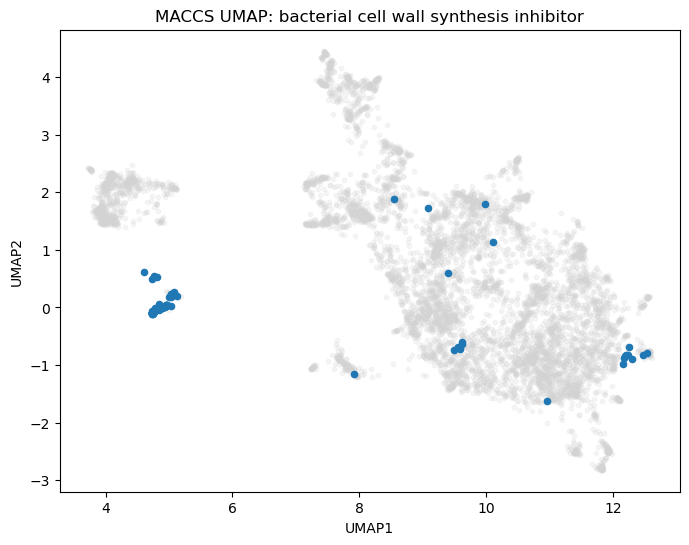

In [36]:
selected_moa = "bacterial cell wall synthesis inhibitor"

# Choose which representation to visualize
subset = maccs_plot_df.copy()

plt.figure(figsize=(8,6))

plt.scatter(
    subset["UMAP1"],
    subset["UMAP2"],
    color="lightgray",
    alpha=0.2,
    s=10
)

highlight = subset[subset["moa"] == selected_moa]

plt.scatter(
    highlight["UMAP1"],
    highlight["UMAP2"],
    s=20
)

plt.title(f"MACCS UMAP: {selected_moa}")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()

In [37]:
def plot_top10_moas(df, title):

    plt.figure(figsize=(10,8))

    for moa in top10_moas:
        subset = df[df["moa"] == moa]

        plt.scatter(
            subset["UMAP1"],
            subset["UMAP2"],
            label=moa,
            alpha=0.7,
            s=20
        )

    plt.title(title)
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")

    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        fontsize=8
    )

    plt.tight_layout()
    plt.show()

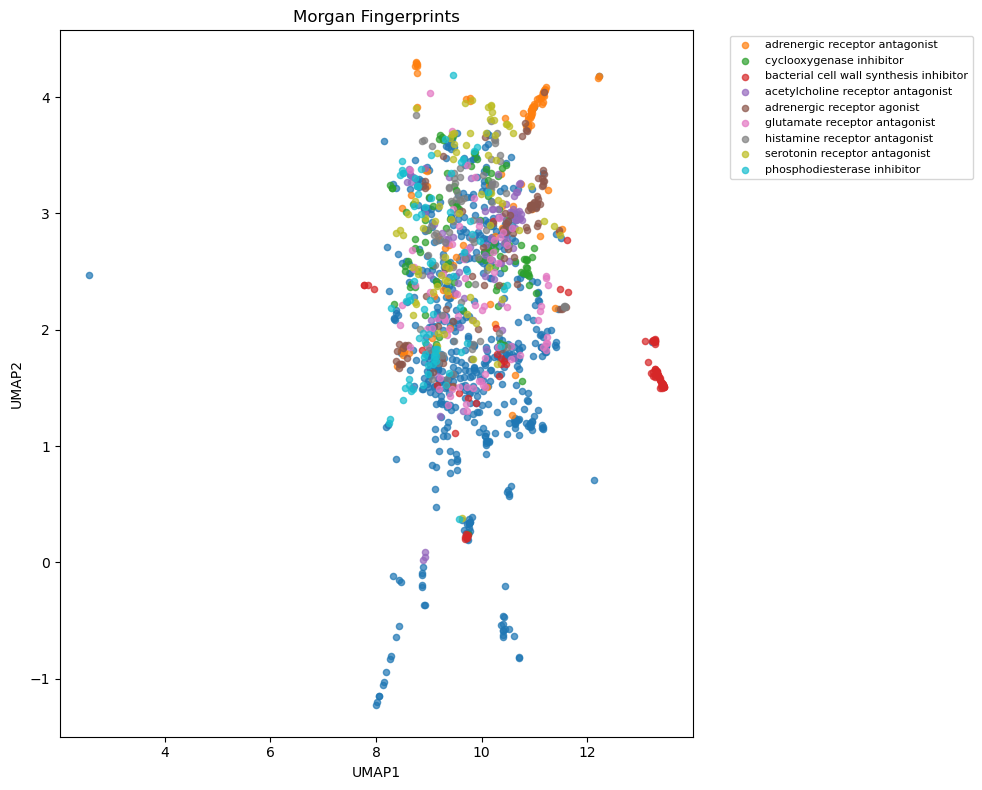

In [38]:
plot_top10_moas(morgan_plot_df, "Morgan Fingerprints")

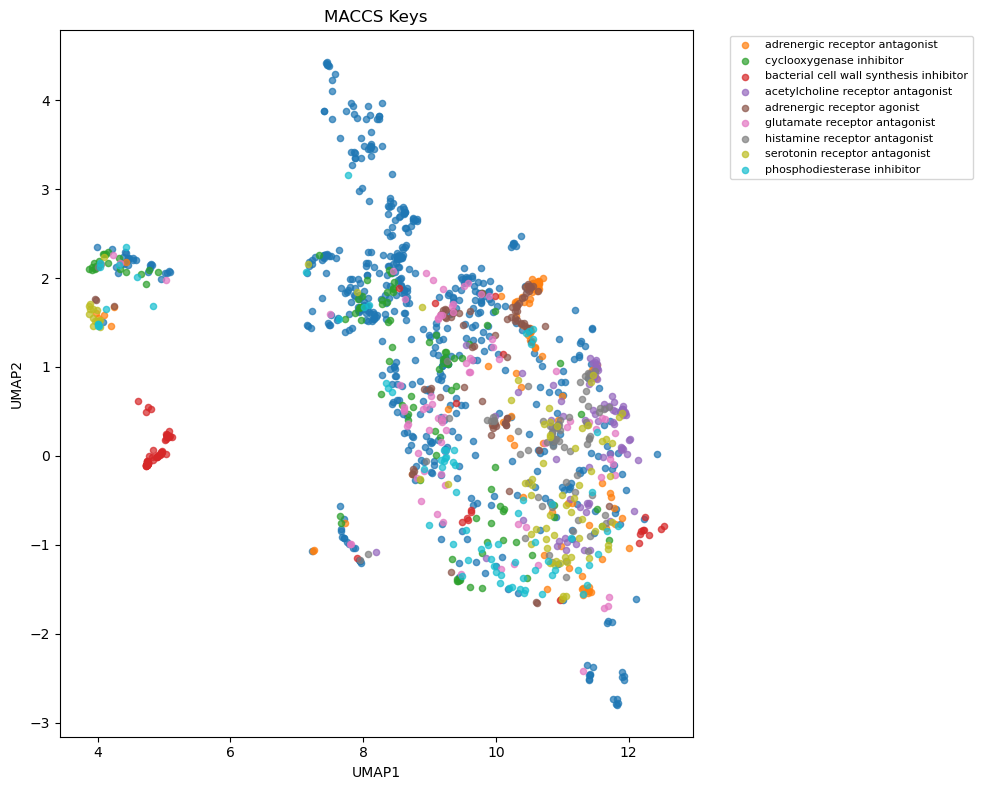

In [39]:
plot_top10_moas(maccs_plot_df, "MACCS Keys")

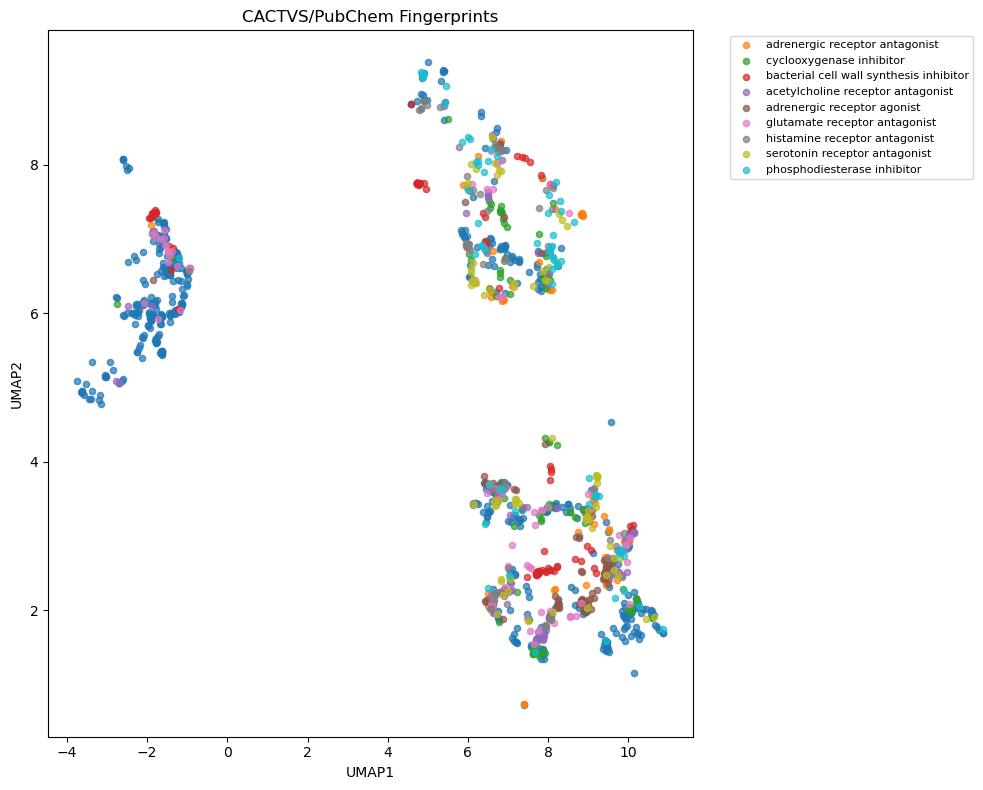

In [40]:
plot_top10_moas(cactvs_plot_df, "CACTVS/PubChem Fingerprints")

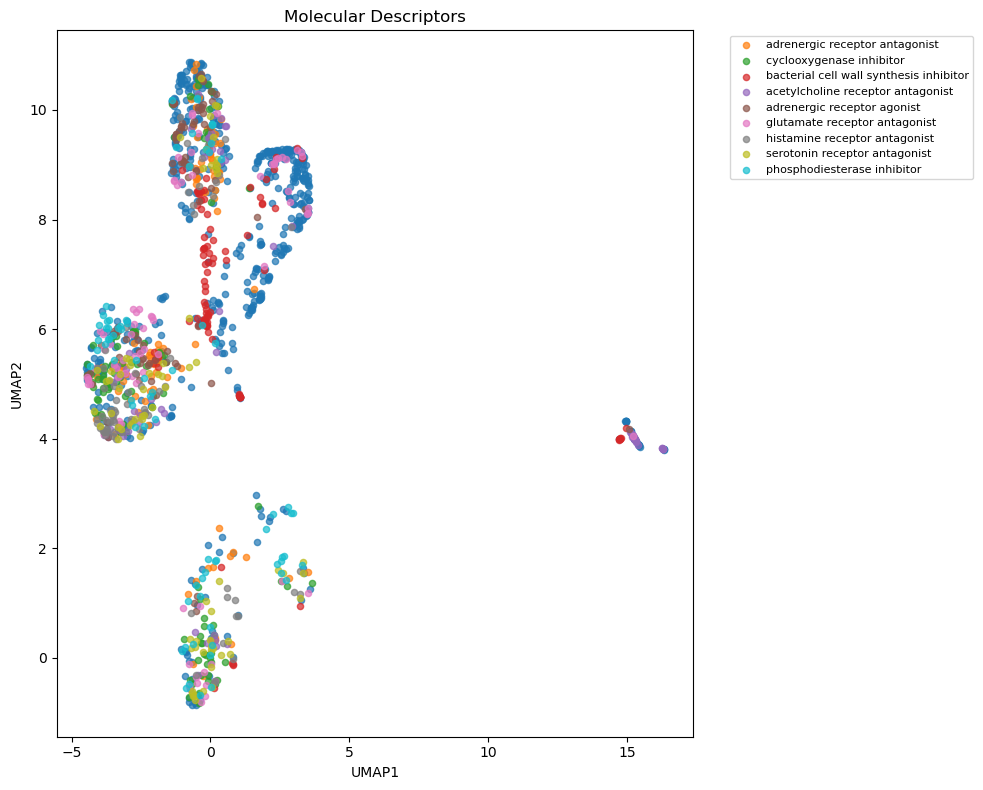

In [41]:
plot_top10_moas(descriptors_plot_df, "Molecular Descriptors")

In [42]:
import os

print(os.getcwd())

/Users/mell/predicting-predictability/notebooks
